In [1]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[4], "Rep_V": col_m[2]} 
model_order = ["Basic", "Rep_M", "Rep_Z"]

In [13]:
ds = xr.load_dataset(f"results/results_summary/Rep_M/params_results.nc")
ds = ds[params]
ds

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 22563)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
Data variables:
    alpha            (ensembl_gene_id) float32 10.81 0.7898 43.13 ... 2.364 1.49
    beta             (ensembl_gene_id) float32 1.157 1.376 ... 0.4292 5.304
    delta_m          (ensembl_gene_id) float32 0.3144 0.06426 ... 0.4088 0.2056
    delta_z          (ensembl_gene_id) float32 0.9462 0.1188 ... 0.1429 0.5514
    t_zga            (ensembl_gene_id) float32 0.4756 12.74 ... 6.106 0.4792
    t_reg            (ensembl_gene_id) float32 2.815 43.47 2.415 ... 10.83 10.63

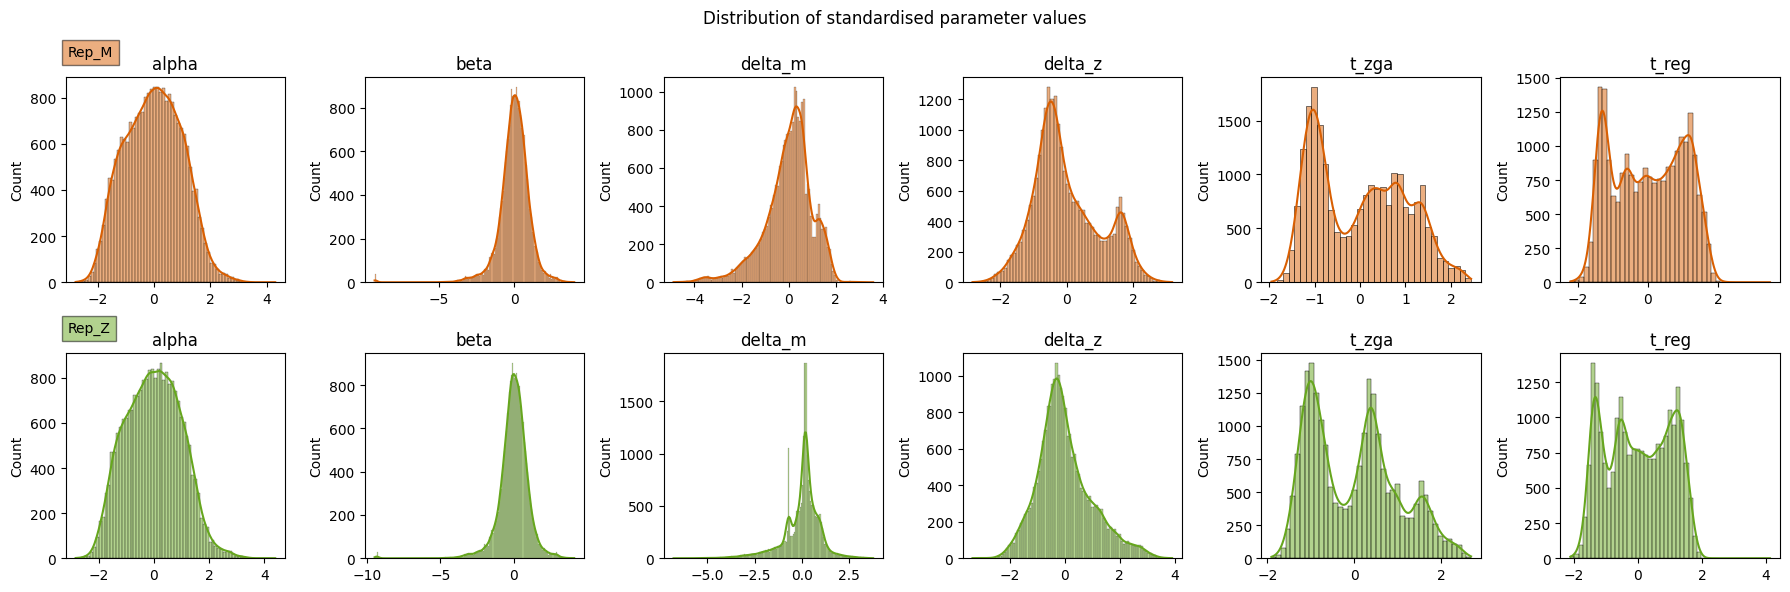

In [48]:
# plot params distribution

params = [ "alpha", "beta", "delta_m", "delta_z", "t_zga", "t_reg"]
params = [ "alpha", "beta", "delta_m", "delta_z", "t_zga", "t_reg"]

models = ["Rep_M", "Rep_Z"]
fig, ax = plt.subplots(len(models), len(params), figsize=(3*len(params), 3*(len(models)))) 

for n, model in enumerate(models):
    ds = xr.load_dataset(f"results/results_summary/{model}/params_results.nc")[params]

    x = np.log(ds)
    u = x.mean()
    s= x.std()

    z_x = (x-u)/s

    for i, par in enumerate(params):
        sns.histplot(z_x[par], ax=ax[n][i], color=mod_color_dict[model], kde=True)
        ax[n][i].set(title= par)
    ax[n][0].text(0.01,1.1, s=f"{model}", transform=ax[n][0].transAxes, bbox=dict(facecolor=mod_color_dict[model], alpha=0.5))

plt.suptitle(f"Distribution of standardised parameter values")
plt.tight_layout()
plt.savefig(f"clustering/figs/param_dist.png", dpi=300)
plt.show()

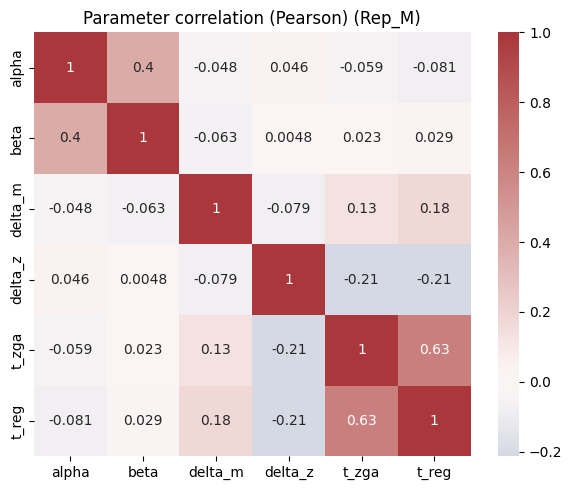

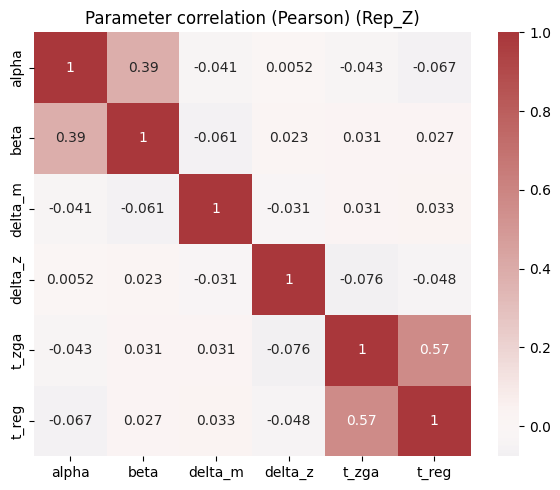

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
params = [ "alpha", "beta", "delta_m", "delta_z", "t_zga", "t_reg"]
models = ["Rep_M", "Rep_Z"]
for model in models:
    ds = xr.load_dataset(f"results/results_summary/{model}/params_results.nc")
    df = ds[params].to_dataframe()
    plt.figure(figsize=(6, 5))
    sns.heatmap(df.corr(method="pearson"),    annot=True,    cmap="vlag",    center=0,)
    plt.title(f"Parameter correlation (Pearson) ({model})")
    plt.tight_layout()
    plt.show()

In [2]:
genes = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc").ensembl_gene_id.values

res_z = pd.read_csv("results/results_summary/Rep_Z/fit_scorecard_flagged.csv")
res_m = pd.read_csv("results/results_summary/Rep_M/fit_scorecard_flagged.csv")
res_b = pd.read_csv("results/results_summary/Basic/fit_scorecard_flagged.csv")

cluster = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc")
cluster_order = ["SD", "DSD", "SU", "DSU"]
cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": cluster["ensembl_gene_id"].values,
    "supercluster_no": cluster["supercluster"].values,
    "subcluster_no": cluster["subcluster"].values,
}).set_index("ensembl_gene_id")
lookup["supercluster"]=lookup["supercluster_no"].map(cluster_names)

# Map onto df by gene_id
for df in [res_b, res_z, res_m]:
    df["supercluster"] = df["gene"].map(lookup["supercluster"])
    df["subcluster"] = df["gene"].map(lookup["subcluster_no"])

res_b = res_b[res_b.gene.isin(genes)]
res_z = res_z[res_z.gene.isin(genes)]
res_m = res_m[res_m.gene.isin(genes)]

res_b["model"] = "Basic"
res_z["model"] = "Rep_Z"
res_m["model"] = "Rep_M"

res = pd.concat([res_b, res_z, res_m], axis=0, ignore_index=True)

#res["good_fit_r2"] = res["r2"] >= 0.7
#res["good_fit"] = res["nrmse_range"] <= 0.2

res["converged"] = (res["rhat_max"] <= 1.05) & (res["ess_bulk_min"] >= 400) 
res

C:\Users\mgrho\AppData\Local\Temp\ipykernel_16576\2357525356.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_m["model"] = "Rep_M"


,gene,rhat_max,ess_bulk_min,ess_tail_min,convergence_error,n_divergences,frac_divergences,loo,loo_se,p_loo,...,load_error,converged,good_fit_r2,good_fit,reliable_loo,well_calibrated,status,supercluster,subcluster,model
0,ENSDARG00000000019,1.00,7701.0,4765.0,NaN,0,0.000000,-5.719403,5.559465,2.666276,...,NaN,True,False,True,True,True,good,SD,1.0,Basic
1,ENSDARG00000000068,1.00,6869.0,4900.0,NaN,0,0.000000,-61.596542,5.332585,1.921278,...,NaN,True,False,False,True,True,converged_poor_fit,SD,1.0,Basic
2,ENSDARG00000000018,1.00,6808.0,4829.0,NaN,0,0.000000,-50.956989,8.697937,3.337950,...,NaN,True,False,False,True,True,converged_poor_fit,DSD,1.0,Basic
3,ENSDARG00000000001,1.00,7587.0,5176.0,NaN,0,0.000000,-47.368093,13.946546,4.972525,...,NaN,True,False,False,False,True,converged_poor_fit,SD,2.0,Basic
4,ENSDARG00000000002,1.00,5033.0,4235.0,NaN,0,0.000000,-35.113083,8.170722,3.033907,...,NaN,True,False,False,True,True,converged_poor_fit,DSU,2.0,Basic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67684,ENSDARG00000116591,2.76,5.0,4.0,NaN,31,0.003875,-60.039553,16.183958,13.167287,...,NaN,False,False,False,False,True,non_converged,SU,0.0,Rep_M
67685,ENSDARG00000116401,2.26,6.0,13.0,NaN,176,0.022000,-52.523698,8.214629,10.201807,...,NaN,False,False,True,False,True,non_converged,SD,1.0,Rep_M
67686,ENSDARG00000116694,1.53,8.0,1990.0,NaN,986,0.123250,14.655066,18.028386,16.854177,...,NaN,False,False,True,False,True,non_converged,SD,0.0,Rep_M
67687,ENSDARG00000116902,9.43,4.0,4.0,NaN,0,0.000000,-21.254843,6.753702,3.123273,...,NaN,False,False,False,False,True,non_converged,SD,1.0,Rep_M


c:\Users\mgrho\Expression_baseline_models\plots\plot_scorecard_summary.py:116: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([format_label(t.get_text()) for t in ax.get_yticklabels()])
c:\Users\mgrho\Expression_baseline_models\plots\plot_scorecard_summary.py:116: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([format_label(t.get_text()) for t in ax.get_yticklabels()])
c:\Users\mgrho\Expression_baseline_models\plots\plot_scorecard_summary.py:116: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([format_label(t.get_text()) for t in ax.get_yticklabels()])


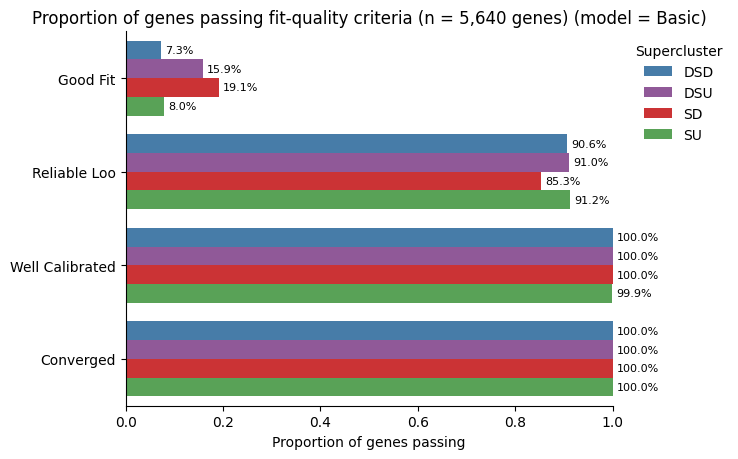

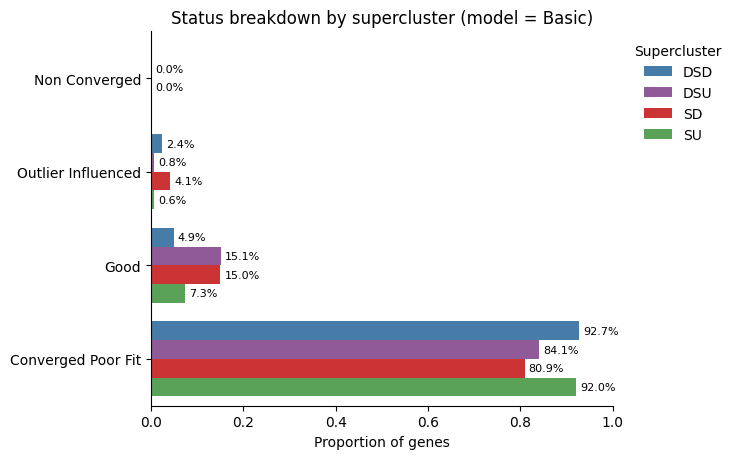

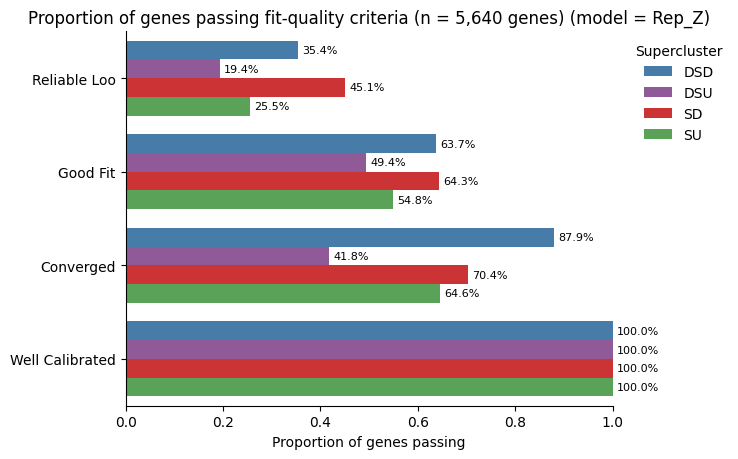

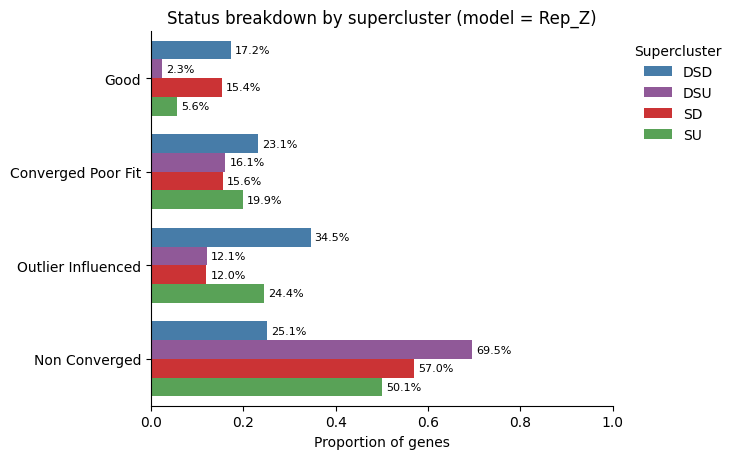

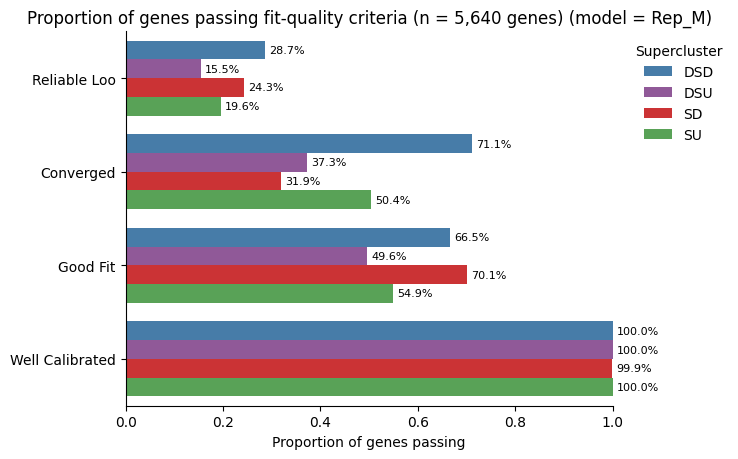

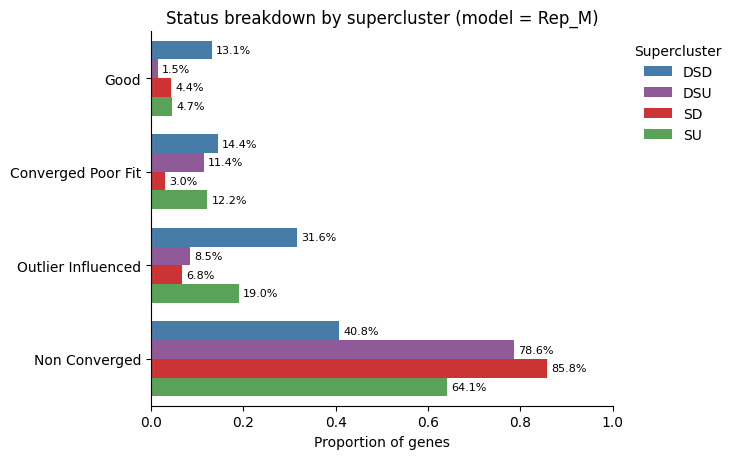

In [3]:
from plots.plot_scorecard_summary import *

for m in res.model.unique():
    res1 = res[res["model"] == m].copy()
    plot_pass_rates(res1, hue="supercluster", title=m)
    plot_status_breakdown(res1, hue="supercluster", title=m)

c:\Users\mgrho\Expression_baseline_models\plots\plot_scorecard_summary.py:112: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([format_label(t.get_text()) for t in ax.get_yticklabels()])


<Axes: title={'center': 'Status breakdown by model variant'}, xlabel='Proportion of genes (within model variant)'>

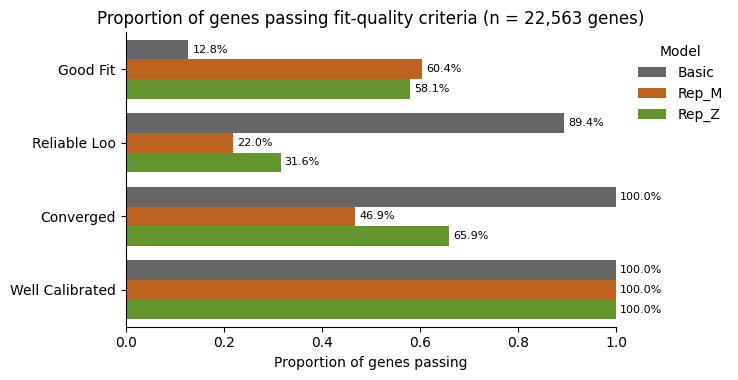

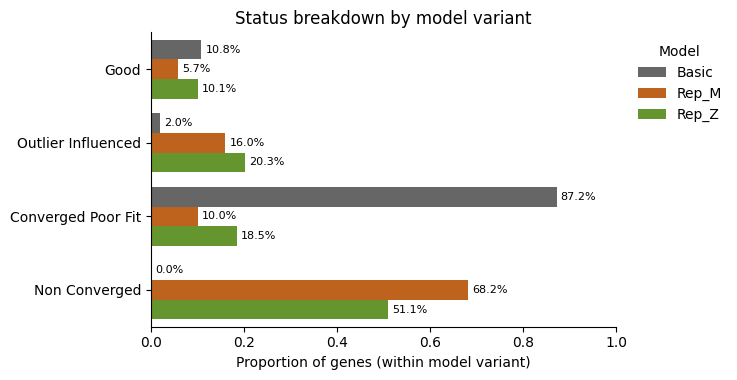

In [5]:
from plots.plot_scorecard_summary import *
plot_pass_rates(res, hue="model")
plot_status_breakdown(res, hue="model")


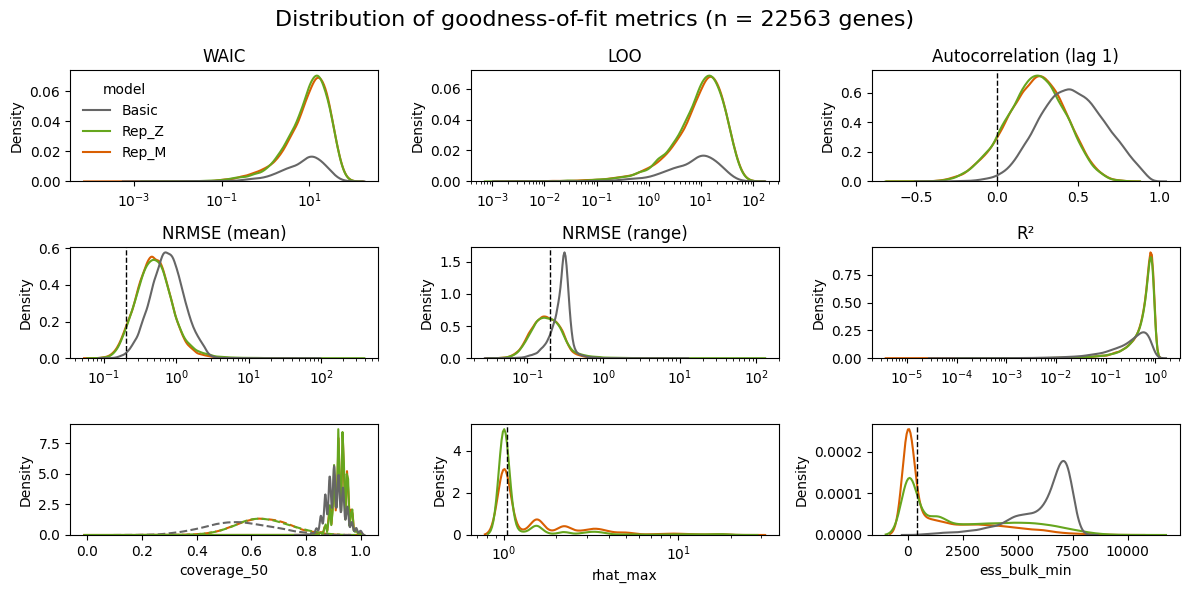

In [23]:
d = res#[(res["nrmse_mean"] < 100) & (res["r2"] > 0.1)].copy()
d1 = res[res["model"] != "Basic"]
d1 = d1[d1["rhat_max"] <= 100]
genes = d.gene.nunique()

fig, ax = plt.subplots(3,3, figsize=(12, 6))
ax = ax.flatten()

metrics=["WAIC", "LOO", "Autocorrelation (lag 1)", "NRMSE (mean)", "NRMSE (range)", "R²"]

args = {
    #"bins": 80,
    "log_scale": True,
    "hue": "model",
    "palette": mod_color_dict,
    #"kde": True,
    #"alpha": 0.1,
    #"element": "step",
    #"stat": "density",
    "legend": False,
}

args0 = args.copy()
args0["legend"] = True

args1 = args.copy()
args1["log_scale"] = False

sns.kdeplot(data=d, x="waic", ax=ax[0], **args0)
sns.kdeplot(data=d, x="loo", ax=ax[1], **args)
sns.kdeplot(data=d, x="resid_autocorr_lag1", **args1, ax=ax[2])
ax[2].axvline(0, color="black", ls="--", lw=1, label="Optimum (0.0)")

sns.kdeplot(data=d, x="nrmse_mean", ax=ax[3], **args)
sns.kdeplot(data=d, x="nrmse_range",ax=ax[4],**args)
sns.kdeplot(data=d, x="r2",ax=ax[5], **args)
ax[4].axvline(0.2, color="black", ls="--", lw=1, label="Threshold (0.2)")
ax[3].axvline(0.2, color="black", ls="--", lw=1, label="Threshold (0.2)")


args2 = args.copy()
args2["log_scale"] = False
sns.kdeplot(data=d, x="coverage_50", **args2, ax=ax[6], ls="--")
sns.kdeplot(data=d, x="coverage_90", **args2,  ax=ax[6],)
sns.kdeplot(data=d1, x="rhat_max", **args,  ax=ax[7],)
sns.kdeplot(data=d, x="ess_bulk_min", **args2,  ax=ax[8],)
ax[8].axvline(400, color="black", ls="--", lw=1, label="Threshold")
ax[7].axvline(1.05, color="black", ls="--", lw=1, label="Threshold")

sns.move_legend(ax[0], "upper left", frameon=False)

for i in range(len(metrics)):
    ax[i].set(title=metrics[i], xlabel="")

plt.suptitle(f"Distribution of goodness-of-fit metrics (n = {genes} genes)", fontsize=16)
plt.tight_layout()
plt.savefig(f"figures/gof_distribution.png", dpi=300)

In [4]:
res.columns

Index(['gene', 'rhat_max', 'ess_bulk_min', 'ess_tail_min', 'convergence_error',
       'n_divergences', 'frac_divergences', 'loo', 'loo_se', 'p_loo',
       'max_pareto_k', 'frac_pareto_k_high', 'loo_error', 'waic', 'waic_se',
       'rmse', 'mae', 'nrmse_range', 'nrmse_mean', 'r2', 'coverage_50',
       'coverage_90', 'fit_error', 'resid_autocorr_lag1', 'load_error',
       'converged', 'good_fit_r2', 'good_fit', 'reliable_loo',
       'well_calibrated', 'status', 'model'],
      dtype='object')

In [ ]:
transcript_data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 12))
obs = transcript_data.sel(ensembl_gene_id="ENSDARG00000000086").tpm.to_dataset(name="y") 
#plt.plot(obs.time, obs.y, "o")

obs = transcript_data.sel(ensembl_gene_id="ENSDARG00000000001").tpm.to_dataset(name="y")
obs2 = np.log2(obs)
cond = (obs2["y"] >= -3) | obs2["y"].isnull()
obs2["y"] = obs2["y"].where(cond, -3)
plt.plot(obs2.time, obs2.y, "o")
plt.plot(obs1.time, obs1.y, "s")

In [96]:
idata = az.from_netcdf("results/ENSDARG00000000086/numpyro_posterior.nc")
idata.sample_stats.diverging

<xarray.DataArray 'diverging' (chain: 4, draw: 2000)>
[8000 values with dtype=bool]
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 1993 1994 1995 1996 1997 1998 1999
    cluster  (chain) int64 ...

In [5]:
az.summary(idata, group="posterior", var_names=None)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,14.843,4.354,8.136,22.979,0.059,0.086,6487.0,5460.0,1.0
beta,2.698,1.345,0.604,5.119,0.018,0.020,5555.0,5175.0,1.0
delta_m,0.498,0.600,0.016,1.341,0.008,0.027,7891.0,6104.0,1.0
delta_z,0.181,0.092,0.039,0.349,0.001,0.001,5908.0,5307.0,1.0
sigma_y,0.450,0.043,0.370,0.530,0.001,0.001,7538.0,5676.0,1.0
t_rep,1.916,0.509,0.975,2.867,0.006,0.006,6363.0,4985.0,1.0
t_zga,0.443,0.167,0.132,0.741,0.002,0.002,5475.0,4198.0,1.0
t_reg,2.359,0.467,1.467,3.195,0.006,0.005,6903.0,5119.0,1.0


In [6]:
pareto_k = az.loo(idata, pointwise=True).pareto_k.values
finite_k = pareto_k[~np.isinf(pareto_k)]
max_k = finite_k.max() if finite_k.size > 0 else np.nan
max_k

c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


0.34649366944555254

In [13]:
print(idata.log_likelihood)

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 2000, time: 50, source: 4)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 1993 1994 1995 1996 1997 1998 1999
  * time     (time) float64 0.0 0.75 0.875 1.29 2.25 ... 92.88 96.0 103.2 120.0
  * source   (source) <U5 'BK' 'JN' 'Pauli' 'White'
    cluster  (chain) int64 0 0 0 0
Data variables:
    y        (chain, draw, time, source) float32 0.0 0.0 0.0 ... -3.378 -0.1394
Attributes:
    created_at:     2026-07-31T22:02:47.031137+00:00
    arviz_version:  0.21.0


In [24]:
idata = az.from_netcdf("results/ENSDARG00000000212/numpyro_posterior.nc")


ll = idata.log_likelihood["y"]  # dims: (chain, draw, time, source)
grouped_ll = ll.sum(dim="source")   # -> dims: (chain, draw, time)

# Wrap into a fresh InferenceData for WAIC/LOO
idata_grouped = az.InferenceData(
    posterior=idata.posterior,          # reuse original posterior
    log_likelihood=xr.Dataset({"y": grouped_ll}),
)
idata_grouped
#a)
az.loo(idata_grouped, pointwise=True)


c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 50 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -44.64     7.92
p_loo        6.46        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       49   98.0%
   (0.70, 1]   (bad)         1    2.0%
   (1, Inf)   (very bad)    0    0.0%

In [ ]:
#b)
az.loo(idata, pointwise=True)

c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 200 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -43.61     7.61
p_loo        4.87        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       62   31.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)  138   69.0%

### Determine Noise level of dataset


In [2]:
tpm = pd.read_csv("data/White_Pauli_JN_BK/tpms_white_pauli_JN_BK.csv")
samples = pd.read_csv("data/White_Pauli_JN_BK/samples_white_pauli_JN_BK.csv")

meta = tpm[["ensembl_gene_id","ensembl_transcript_id","transcript_length","transcript_is_canonical","external_gene_name"]]
meta.to_csv("data/meta_data.csv", index=False)

tpm_long = tpm.melt(
    id_vars=["ensembl_gene_id", "ensembl_transcript_id", "transcript_length"],
    var_name="sample_id",
    value_vars=samples["sample_id"].unique(),
    value_name="tpm_values"
    )
#Merge with metadata
combined_df = tpm_long.merge(samples, on="sample_id", how="left")
combined_df.head()

agg = combined_df.groupby(["source", "time_hpf_standard", "ensembl_gene_id", "sample_id"])["tpm_values"].sum().reset_index()
agg_mean = (
    agg.groupby(["time_hpf_standard", "ensembl_gene_id", "source"], observed=True)
    .agg(tpm=("tpm_values", "mean"),))

dataset = agg_mean.to_xarray().rename({"time_hpf_standard": "time"}) 
dataset = dataset.assign_attrs(
    description="RNA-seq data from multiple sources: White et al. (2017), Pauli et al. (2011), BK, JN.",
    units="TPM")
dataset.head()

<xarray.Dataset>
Dimensions:          (time: 5, ensembl_gene_id: 5, source: 4)
Coordinates:
  * time             (time) float64 0.0 0.75 0.875 1.29 2.25
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * source           (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 66.61
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

In [3]:
df1 = combined_df.groupby(["source", "time_hpf_standard", "ensembl_gene_id", "sample_id"])["tpm_values"].sum().to_xarray().rename({"time_hpf_standard": "time"}) 


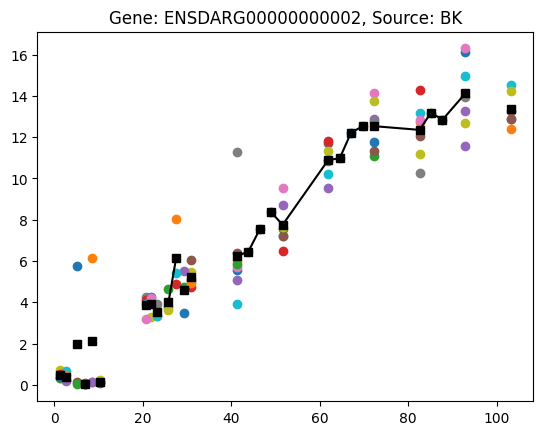

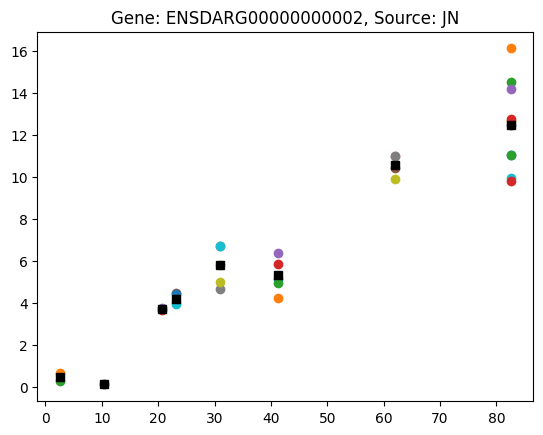

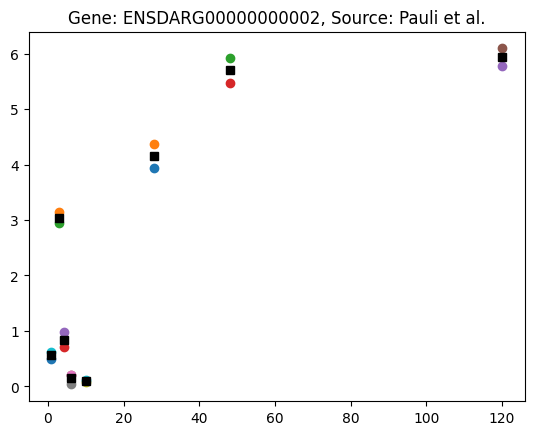

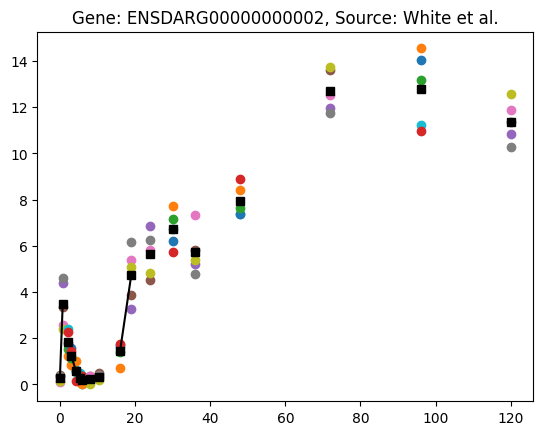

In [6]:
gene = "ENSDARG00000000002"
mean_tpm = df1.sel(ensembl_gene_id=gene).mean(dim="sample_id", skipna=True)
d = df1.sel(ensembl_gene_id=gene)
for sc in d.source.values:
    fig, ax = plt.subplots()
    ax.plot(d.time, d.sel(source=sc), "o")
    ax.plot(mean_tpm.time, mean_tpm.sel(source=sc).values, "k-s")
    ax.plot()
    ax.set_title(f"Gene: {gene}, Source: {sc}")


In [4]:
# check number of replicates per sample
rep_counts = (
    agg.groupby(["source", "time_hpf_standard"])["sample_id"]
    .nunique()
    .reset_index(name="n_replicates")
)
print(rep_counts.pivot(index="time_hpf_standard", columns="source", values="n_replicates"))

source              BK    JN  Pauli et al.  White et al.
time_hpf_standard                                       
0.000              NaN   NaN           NaN           5.0
0.750              NaN   NaN           NaN           5.0
0.875              NaN   NaN           2.0           NaN
1.290              5.0   NaN           NaN           NaN
2.250              NaN   NaN           NaN           5.0
2.580              4.0   2.0           NaN           NaN
3.000              NaN   NaN           2.0           5.0
4.300              NaN   NaN           NaN           5.0
4.330              NaN   NaN           2.0           NaN
5.160              3.0   NaN           NaN           NaN
5.250              NaN   NaN           NaN           5.0
6.000              NaN   NaN           3.0           5.0
6.880              4.0   NaN           NaN           NaN
8.000              NaN   NaN           NaN           5.0
8.600              3.0   NaN           NaN           NaN
10.000             NaN   NaN   

In [4]:
rep_counts[rep_counts["n_replicates"] > 2].value_counts("source")

source
BK              20
White et al.    18
JN               5
Pauli et al.     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Gene: ENSDARG00000000086')

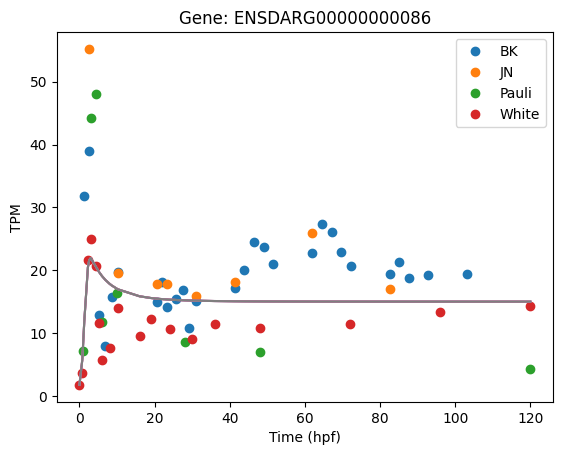

In [164]:
plt.plot(obs.time, obs, "o", label=obs.source.values)
plt.plot(pred.time, pred, "-")
plt.legend()
plt.ylabel("TPM")
plt.xlabel("Time (hpf)")
plt.title("Gene: ENSDARG00000000086")

In [6]:
agg_stats = (
    agg.groupby(["time_hpf_standard", "ensembl_gene_id", "source"], observed=True)
    .agg(
        tpm=("tpm_values", "mean"),
        tpm_range=("tpm_values", lambda x: x.max() - x.min()),
        tpm_std=("tpm_values", "std"),
        n_reps=("tpm_values", "count"),
    )
)

#agg_stats["tpm_nrmse"] = np.sqrt( (agg_stats["tpm"] - agg_stats["tpm"].mean(dim="source"))**2 ) / agg_stats["tpm_range"]  # normalized RMSE
agg_stats["tpm_cv"] = agg_stats["tpm_std"] / agg_stats["tpm"]  # coefficient of variation
agg_stats["sd_range_ratio"] = agg_stats["tpm_std"] / agg_stats["tpm_range"]  # coefficient of variation

ds = agg_stats.to_xarray()
ds

common_mask = (ds['n_reps'] >= 3)  # drop n=1,2 timepoints where CV is undefined or unstable
cv_filtered = ds['tpm_cv'].where(common_mask)
cv_source_filtered = cv_filtered.mean(dim='time_hpf_standard', skipna=True).median(dim='ensembl_gene_id')
cv_source_filtered

cv_q90 = cv_filtered.mean(dim='time_hpf_standard', skipna=True).quantile(0.9, dim='ensembl_gene_id')
cv_q90

In [44]:
cv_filtered = ds['tpm_cv'].where(common_mask)
cv_source_filtered = cv_filtered.mean(dim='time_hpf_standard', skipna=True).median(dim='ensembl_gene_id')
cv_source_filtered

<xarray.DataArray 'tpm_cv' (source: 4)>
array([0.37341639, 0.22111665, 0.16644359, 0.60552136])
Coordinates:
  * source   (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'

In [45]:
cv_filtered = ds['sd_range_ratio'].where(common_mask)
cv_source_filtered = cv_filtered.mean(dim='time_hpf_standard', skipna=True).median(dim='ensembl_gene_id')
cv_source_filtered.mean()

<xarray.DataArray 'sd_range_ratio' ()>
array(0.44784201)

In [40]:
data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
df = pd.read_csv("results/results_summary/params_combined.csv")

df_out = df[(df["t_reg_mean"] > 120)]
df_out.value_counts("model")

#genes =df.gene_id.values
#for g in genes:
    #plt.figure()
    #plt.plot(data.time, data.sel(ensembl_gene_id=g).tpm, "o-")

model
Rep_M    12
Rep_Z     2
Name: count, dtype: int64

In [ ]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
#ds0.sel(source="BK").dropna(dim="time", how="all", subset=["tpm"])
ds = ds0.sel(ensembl_gene_id="ENSDARG00000000189")
plt.plot(ds.time, ds.tpm, "o")

In [13]:
df["t_m_half"] = np.log(2) / df["delta_m_mean"]
df["t_z_half"] = np.log(2) / df["delta_z_mean"]

df = df[df["t_reg_mean"] < 120.0]

sub_m = df[df["model"] == "Rep_M"].copy()
sub_z = df[df["model"] == "Rep_Z"].copy()

In [ ]:
ds_params = pd.read_csv("results/results_summary/params_combined.csv")
ds_params

df = ds_params[ds_params["model"] != "Basic" ].copy()

df["r"] = df["beta_mean"] / df["alpha_mean"]

df["t_half_m"] = np.log(2) / df["delta_m_mean"]
df["t_half_m"] = np.log(2) / df["delta_m_mean"]


df = df[df["r"] > 1e-5]

param_cluster = df[["gene_id", "model", "r", "t_zga_mean", "t_rep_mean"]].copy()

import numpy as np

param_cluster["t_zga"] = np.minimum(param_cluster["t_zga_mean"],  param_cluster["t_rep_mean"])
param_cluster["t_reg"] = np.maximum(param_cluster["t_zga_mean"],  param_cluster["t_rep_mean"])

param_cluster.loc[param_cluster["r"] > 1, "dir"] = "up"
param_cluster.loc[param_cluster["r"] == 1, "dir"] = "none"
param_cluster.loc[param_cluster["r"] < 1, "dir"] = "down"


param_cluster.loc[param_cluster["t_zga"] < 2, "activation"] = "early"
param_cluster.loc[(param_cluster["t_zga"] <= 4) & (param_cluster["t_zga"] >= 2) , "activation"] = "zga"
param_cluster.loc[param_cluster["t_zga"] > 4, "activation"] = "late"

#param_cluster.loc[param_cluster["t_reg_mean"] < 2, "activation"] = "early"
#param_cluster.loc[(param_cluster["t_reg_mean"] <= 4) & (param_cluster["t_zga_mean"] >= 2) , "activation"] = "zga"
#param_cluster.loc[param_cluster["t_reg_mean"] > 4, "activation"] = "late"

param_cluster

,gene_id,model,r,t_zga_mean,t_rep_mean,t_zga,t_reg,dir,activation
22530,ENSDARG00000000001,Rep_M,0.103700,0.371,2.73,0.371,2.73,down,early
22531,ENSDARG00000000002,Rep_M,1.038095,15.000,33.60,15.000,33.60,up,late
22532,ENSDARG00000000018,Rep_M,0.061503,0.426,2.39,0.426,2.39,down,early
22533,ENSDARG00000000019,Rep_M,0.353435,11.500,17.60,11.500,17.60,down,late
22534,ENSDARG00000000068,Rep_M,0.174372,0.517,4.28,0.517,4.28,down,late
...,...,...,...,...,...,...,...,...,...
67585,ENSDARG00000117792,Rep_Z,0.000640,0.782,4.22,0.782,4.22,down,late
67586,ENSDARG00000117808,Rep_Z,0.577419,2.570,17.70,2.570,17.70,down,late
67587,ENSDARG00000117812,Rep_Z,0.788520,5.350,14.40,5.350,14.40,down,late
67588,ENSDARG00000117815,Rep_Z,0.178390,6.110,10.70,6.110,10.70,down,late


In [14]:
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
gof_src.head()

,gene_id,model,source,BIC,AIC,WAIC,LOO,rho,pearsonr,NRMSE,MASE,accepted,supercluster,supercluster_no,subcluster_no
0,ENSDARG00000000001,Basic,BK,43.276070,37.540001,-47.244569,-47.368093,-0.449918,0.642359,0.210414,0.861284,False,SD,0,0
1,ENSDARG00000000001,Basic,JN,21.126389,15.390320,-47.244569,-47.368093,-0.023810,0.822369,0.312594,0.831596,False,SD,0,0
2,ENSDARG00000000001,Basic,Pauli,30.327650,24.591581,-47.244569,-47.368093,0.833333,0.558843,0.341746,0.815769,False,SD,0,0
3,ENSDARG00000000001,Basic,White,41.197548,35.461479,-47.244569,-47.368093,0.393189,0.507580,0.313140,0.769244,False,SD,0,0
4,ENSDARG00000000002,Basic,BK,28.937088,23.201019,-35.081911,-35.113083,0.982485,0.982436,0.120844,0.318856,True,DSU,3,2


In [16]:
NRMSE_thres = 0.3
RHO_thres = 0.7

cluster_order = ["SD", "DSD", "SU", "DSU"]
cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[3], "Rep_V": col_m[4]} 
model_order = ["Basic", "Rep_M", "Rep_Z"]

col_s = sns.color_palette("twilight_shifted")  
src_color_dict =  {'White':col_s[0], 'Pauli':col_s[1], 'JN':col_s[4], 'BK':col_s[5]}


In [11]:
model_name = "Rep_M"
hue_key = "source"
merged = (gof_src[gof_src["model"] == model_name]).sort_values(["supercluster_no", "gene_id"])
cluster_order = merged.supercluster.dropna().unique()

sources = merged.source.unique()

# Load original data
accepted = merged[(merged["rho"] > RHO_thres) & (merged["NRMSE"] < NRMSE_thres) ]

count_model = accepted[hue_key].value_counts()
count_cluster = accepted.groupby("supercluster")["gene_id"].nunique()

merged_counts = merged.groupby([hue_key, "supercluster"]).size().reset_index(name="merged")
accepted_counts = accepted.groupby([hue_key, "supercluster"]).size().reset_index(name="accepted")
result = pd.merge(merged_counts, accepted_counts, how="left", on=[hue_key, "supercluster"])


## Cluster GOF

In [53]:
ds0 - ds0.mean(dim=("time", "source")) / ds0.std(dim=("time", "source"))

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 36570, time: 50, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... -0.3111

In [111]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")

t_not = [5.16, 8.6, 27.52, 41.28]
mask = ds0.time.isin(t_not)
ds0.sel(time=mask)

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 36570, time: 4, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 5.16 8.6 27.52 41.28
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 1.275 nan ... nan
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

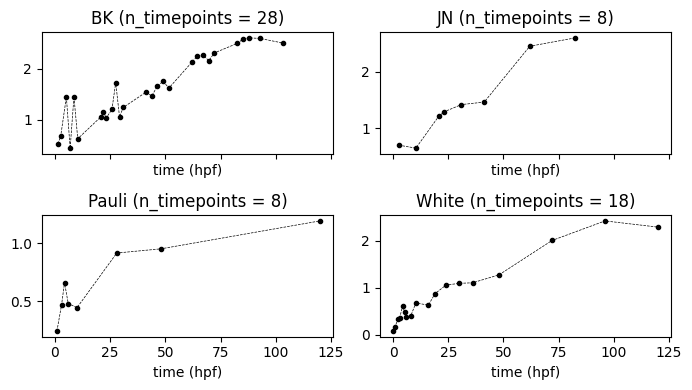

In [34]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")

# t_not = [5.16, 8.6, 27.52, 41.28]
# mask = ~ds0.time.isin(t_not)
# ds0 = ds0.sel(time=mask)

fig, ax = plt.subplots(2,2, figsize=(7, 4), sharex=True)
ax = ax.flatten()

for x, src in enumerate(ds0.source.values):
    ds = ds0.sel(source=src)
    ds = ds.dropna(dim="time", how="all", subset=["tpm"])
    #print(np.isnan(ds["tpm"].values).sum())
    ax[x].plot(ds.time, ds.tpm.median(dim="ensembl_gene_id"), ".--", c="k", lw=0.5)
    ax[x].set(title=f"{src} (n_timepoints = {len(ds.time)})", xlabel="time (hpf)")
plt.tight_layout()

In [47]:
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 24))
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 1).all(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time", "source"))) / ds.tpm.std(dim=("time", "source"))

ds_filtered = ds.sel(ensembl_gene_id=mask)

traj120 = xr.load_dataarray("clustering/results/all_gene_trajectories_24.nc")
gof120 = pd.read_csv("clustering/results/gof_trajectories_24.csv")

#gof120["accepted_r"] = gof120["pearson"] > 0.5
#gof120["accepted_rho"] = gof120["spearman"] > 0.5

print("n genes: ",(gof120.ensembl_gene_id.nunique()))
#gof120.groupby("source").sum("accepted") / gof120.groupby("source").count().drop(columns="ensembl_gene_id")
gof120.groupby("source").mean("accepted")

gene_sums = gof120.groupby("ensembl_gene_id").sum("accepted")
accepted_genes = gene_sums[gene_sums["accepted"] > 0].index.to_list()
rejected_genes = gene_sums[gene_sums["accepted"] == 0].index.to_list()
print(len(accepted_genes))
print(len(rejected_genes))

n genes:  23428
21398
2030


<Axes: xlabel='spearman', ylabel='Density'>

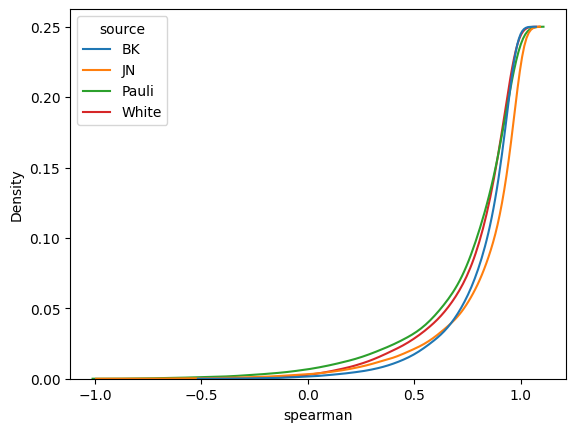

In [40]:
sns.kdeplot(gof120, x="spearman", hue="source", log_scale=False, cumulative=True)

<Axes: xlabel='pearson', ylabel='Density'>

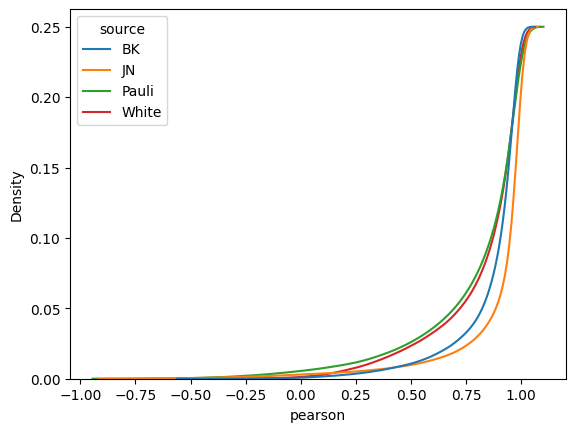

In [41]:
sns.kdeplot(gof120, x="pearson", hue="source", log_scale=False, cumulative=True)

<Axes: xlabel='nrmse', ylabel='Density'>

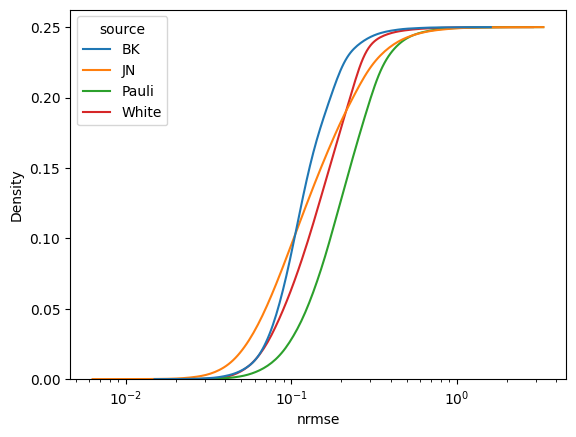

In [42]:
sns.kdeplot(gof120, x="nrmse", hue="source", log_scale=True, cumulative=True)

Mean NRMSE:  source
BK       0.132616
JN       0.165447
Pauli    0.222959
White    0.163626
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (120h)'}, ylabel='Source'>

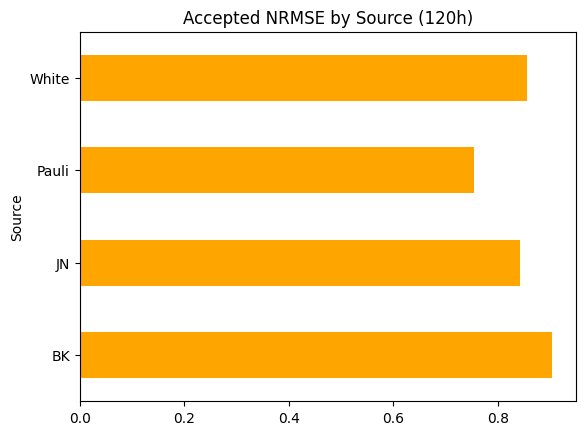

In [43]:
print("Mean NRMSE: ", gof120.groupby("source").nrmse.mean(), "\n")
gof120.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (120h)")
plt.close()
gof120.groupby("source").accepted.mean().plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (120h)")

In [49]:
gene_sums = gof120.groupby("ensembl_gene_id").sum("accepted")
accepted_genes = gene_sums[gene_sums["accepted"] > 0].index.to_list()
rejected_genes = gene_sums[gene_sums["accepted"] == 0].index.to_list()
print(len(accepted_genes))
print(len(rejected_genes))

21398
2030


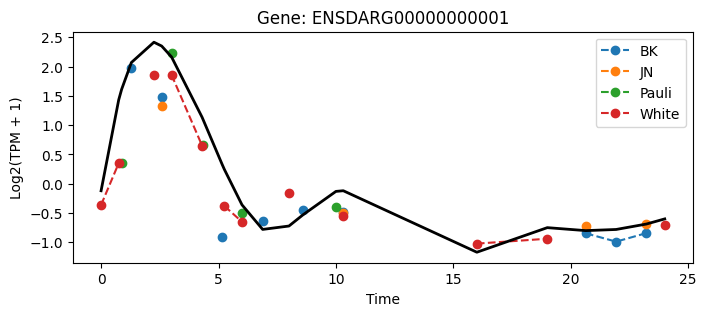

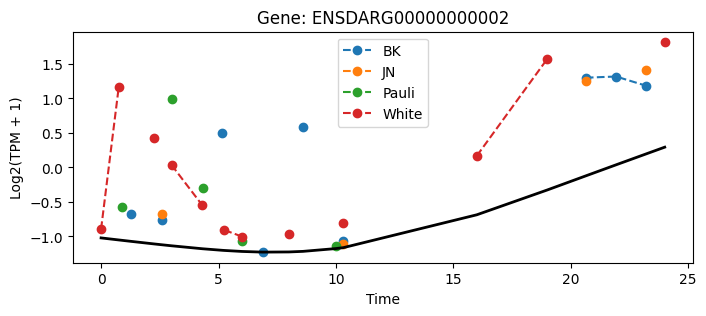

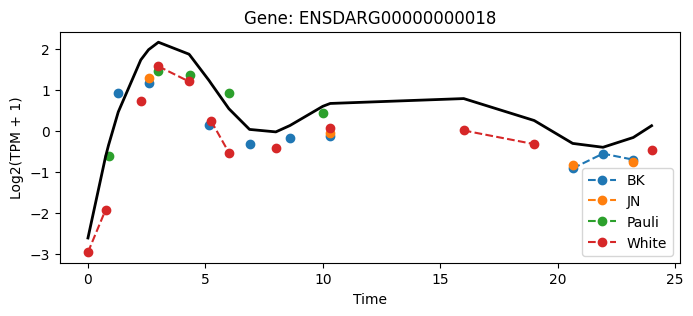

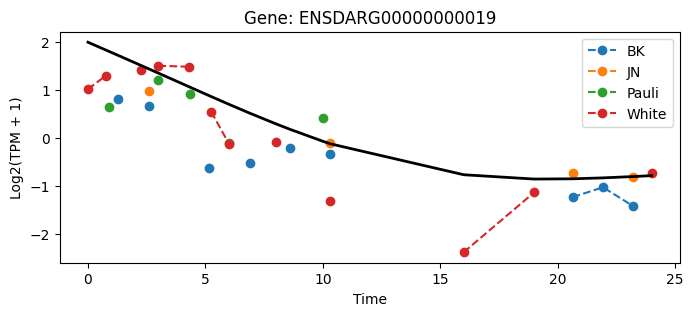

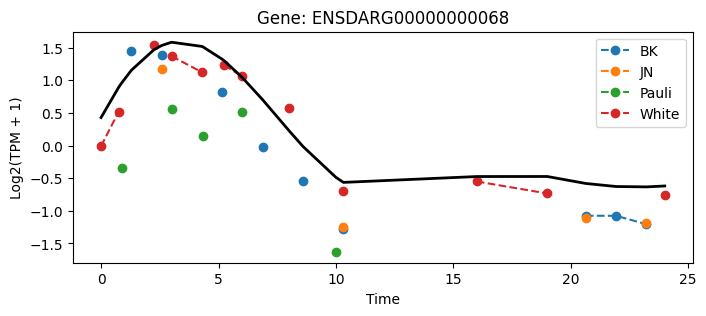

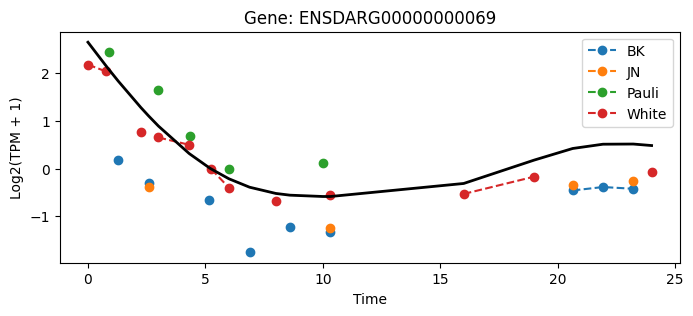

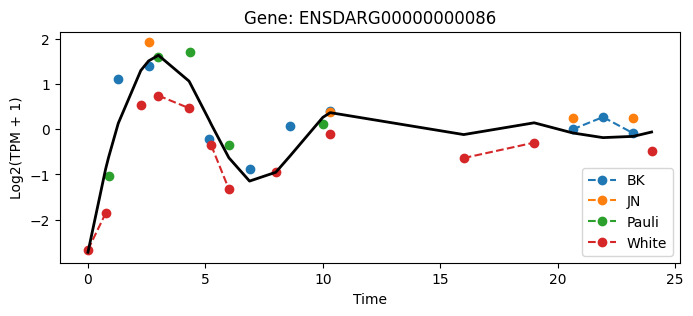

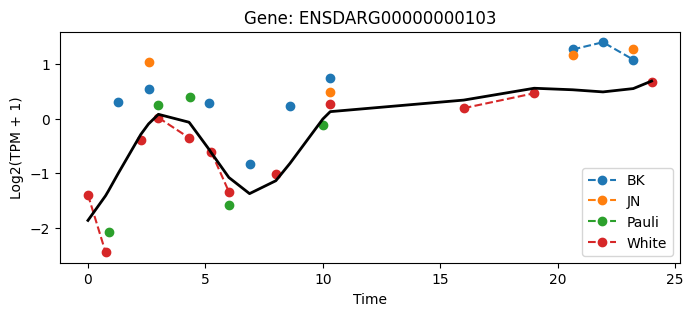

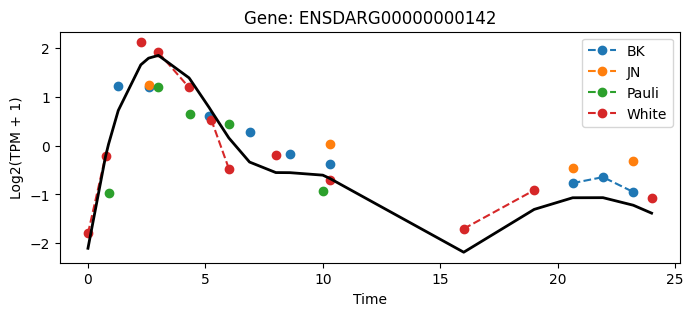

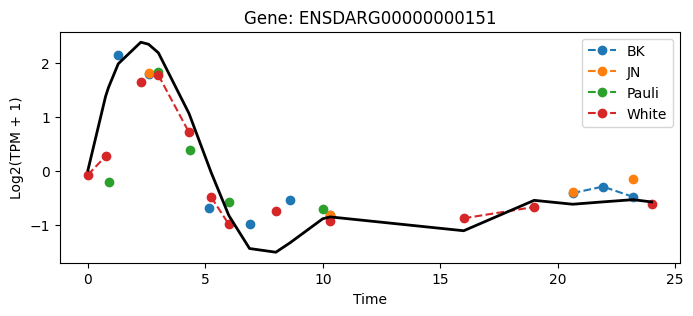

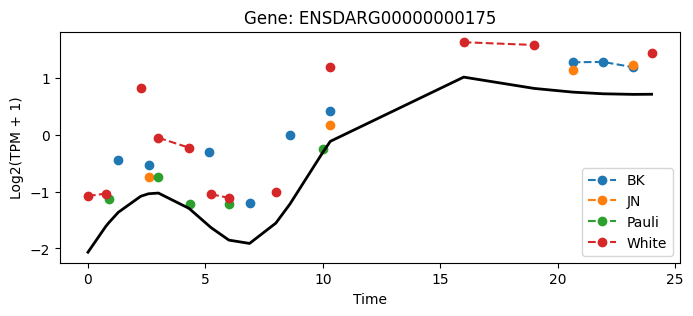

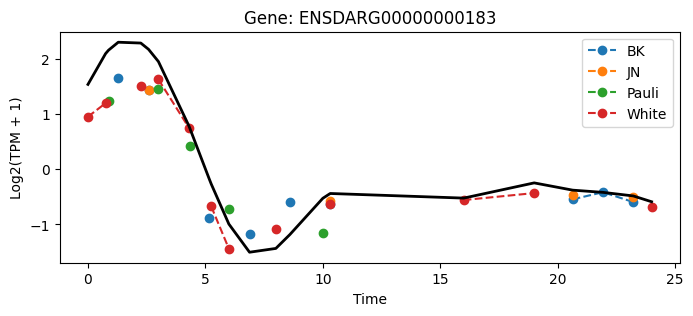

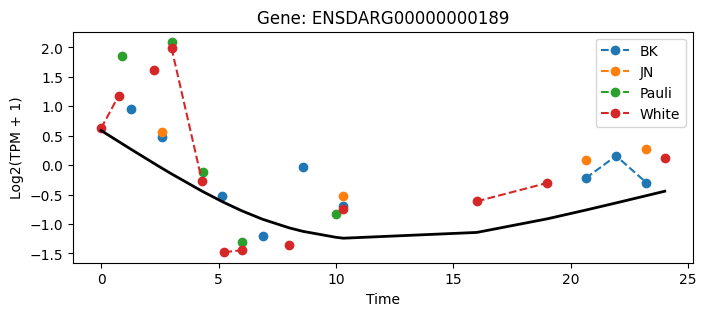

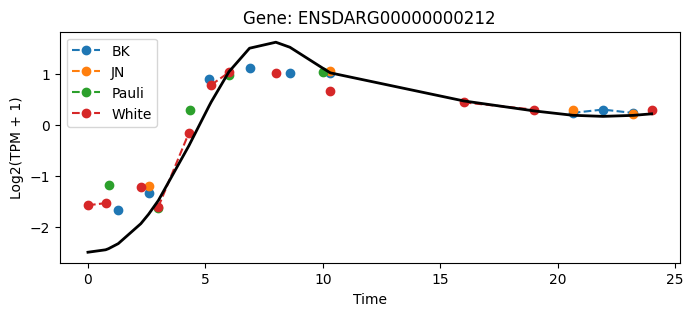

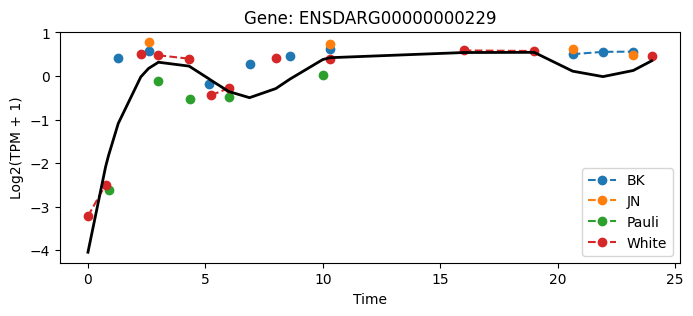

KeyError: "not all values found in index 'ensembl_gene_id'. Try setting the `method` keyword argument (example: method='nearest')."

In [50]:
sc = ds.source.values

for g in accepted_genes[0:20]:
#for g in rejected_genes[0:20]:
    y_true = ds_filtered.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj120.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8, 3))
    plt.plot(ds_filtered.time, y_true, marker="o", ls="--", label=sc)
    plt.plot(ds_filtered.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

### Cluster center GOF

Number of genes in dataset: 22563


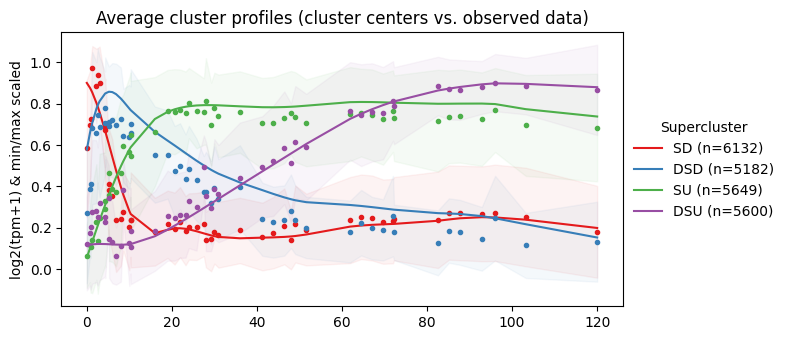

,supercluster,RMSE,r2,spearmanr,pearsonr
0,0,0.095869,0.840922,0.898199,0.919677
1,1,0.125822,0.674107,0.950060,0.965689
2,2,0.052018,0.953898,0.784874,0.985946
3,3,0.083772,0.918571,0.923169,0.972749


In [14]:
def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask])**2)).item()

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

fuzzy_cntr = xr.load_dataarray("clustering/results/all_superclusters_centers.nc")
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time", "source"))) / ds.tpm.std(dim=("time", "source")) #z-score

print(f"Number of genes in dataset: {len(labels.ensembl_gene_id)}")

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
colors = sns.color_palette("Set1", 5)

plt.figure(figsize=(8,3.5))
for c in range(fuzzy_cntr.shape[0]):

    gene_ids = labels['ensembl_gene_id'][labels['supercluster'] == c].values

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))
    #ds_c = zscore(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    center = fuzzy_cntr[c, :]

    plt.plot(fuzzy_cntr.time, center, label=f"{cluster_map[c]} (n={ds_c.ensembl_gene_id.size})", c=colors[c])
    plt.plot(ds_c_mean.time, ds_c_mean, ".", c=colors[c])
    plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("clustering/cluster_validation.xlsx")
    
plt.title("Average cluster profiles (cluster centers vs. observed data)")
plt.ylabel("log2(tpm+1) & min/max scaled")
plt.legend(loc=(1.01, 0.3), frameon=False, title="Supercluster")
plt.tight_layout()
plt.savefig("clustering/figs/cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

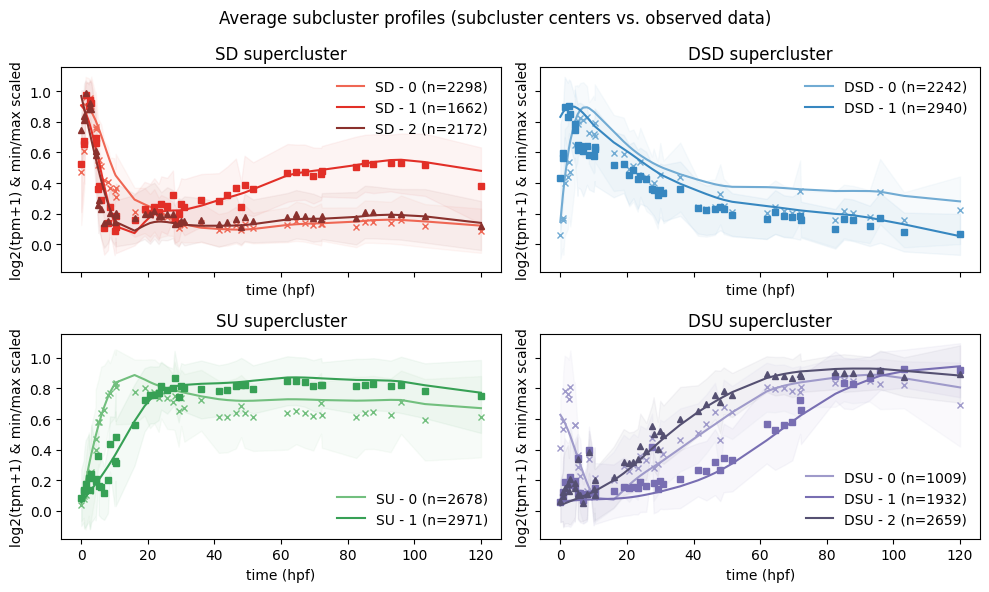

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.117075,0.848344,0.935558,0.945675
1,0,1,0.108215,0.766789,0.895702,0.884489
2,0,2,0.089624,0.867756,0.716879,0.935165
3,1,0,0.128992,0.605521,0.945258,0.970975
4,1,1,0.143658,0.730571,0.974070,0.955946
5,2,0,0.075971,0.859997,0.907131,0.975333
6,2,1,0.057975,0.963947,0.923169,0.983320
7,3,0,0.113683,0.813339,0.913085,0.911337
8,3,1,0.097903,0.879996,0.803025,0.969494
9,3,2,0.076726,0.949725,0.943049,0.983617


In [15]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

mean = ds.tpm.mean(dim=("time", "source"))
std = ds.tpm.std(dim=("time", "source"))
ds["tpm"] = (ds.tpm - mean) / std

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
marker_map = {0:"x", 1:"s", 2:"^"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 3),
             1:sns.color_palette("Blues_d", 3),
             2:sns.color_palette("Greens_d",3),
             3:sns.color_palette("Purples_d",3),}

gof=[]

fig, ax = plt.subplots(2,2, figsize= (10, 6), sharex=True, sharey=True)
ax=ax.flatten()
for k in range(4):

    #fig, ax = plt.subplots(1,1,figsize= (10, 6), squeeze=False)
    #ax=ax.flatten()
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/all_supercluster_{k}_centers.nc")
    for c in range(fuzzy_cntr.shape[0]):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))

        center = fuzzy_cntr[c, :]

        ax[k].plot(fuzzy_cntr.time, center, label=f"{cluster_map[k]} - {c} (n={ds_c.ensembl_gene_id.size})", c=color_map[k][c])
        ax[k].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=color_map[k][c])
        ax[k].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
    ax[k].set(title=f"{cluster_map[k]} supercluster", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
    ax[k].legend(frameon=False)

plt.suptitle("Average subcluster profiles (subcluster centers vs. observed data)")
plt.tight_layout()
plt.savefig(f"clustering/figs/subcluster_validation.png", dpi=300)
plt.show()

pd.DataFrame(gof).to_excel("clustering/subcluster_validation.xlsx")  
pd.DataFrame(gof)

In [16]:
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
labels

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 22563, time: 50, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000032919' ... 'ENSDA...
    supercluster     (ensembl_gene_id) int32 2 2 0 1 2 2 1 2 ... 3 0 1 1 0 3 2 0
    subcluster       (ensembl_gene_id) int32 0 1 1 0 0 1 1 1 ... 1 2 1 1 0 1 0 1
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 4.32
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

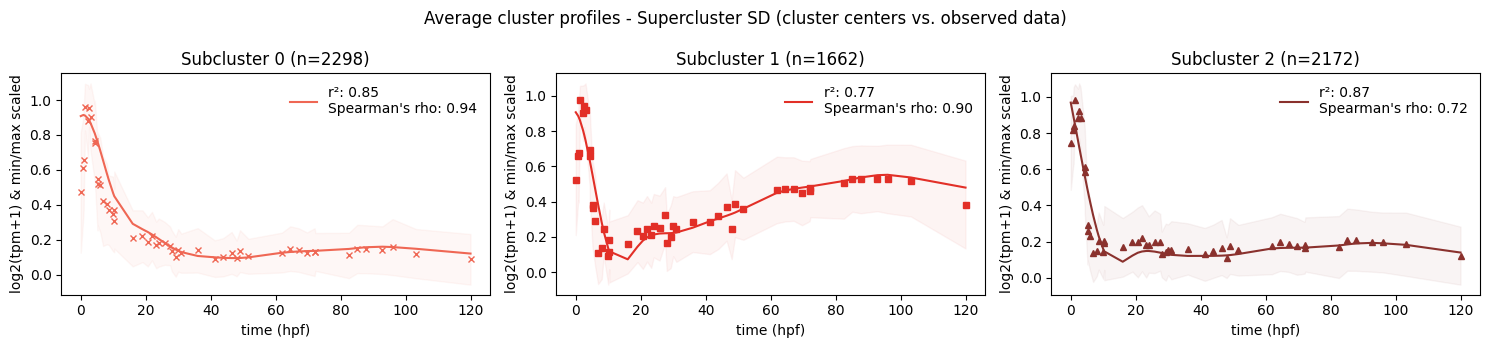

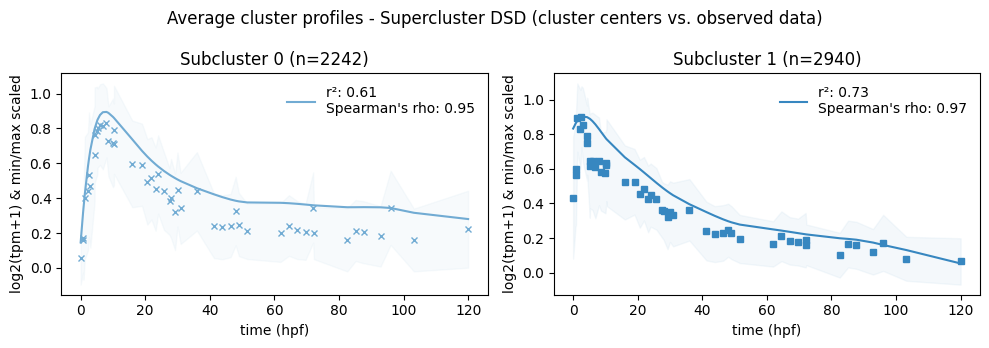

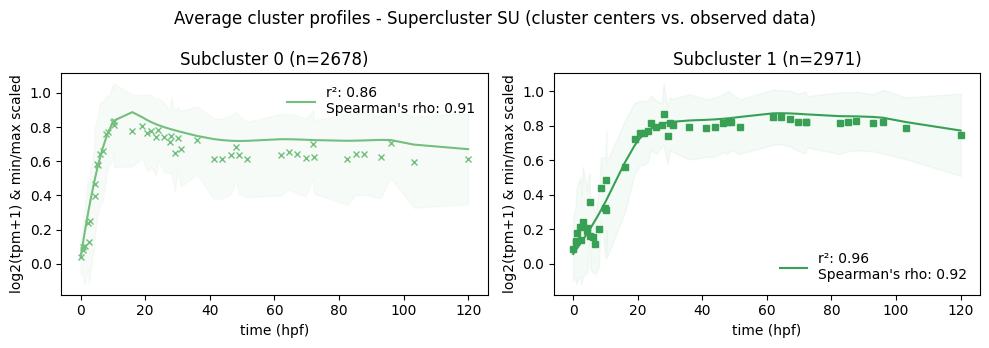

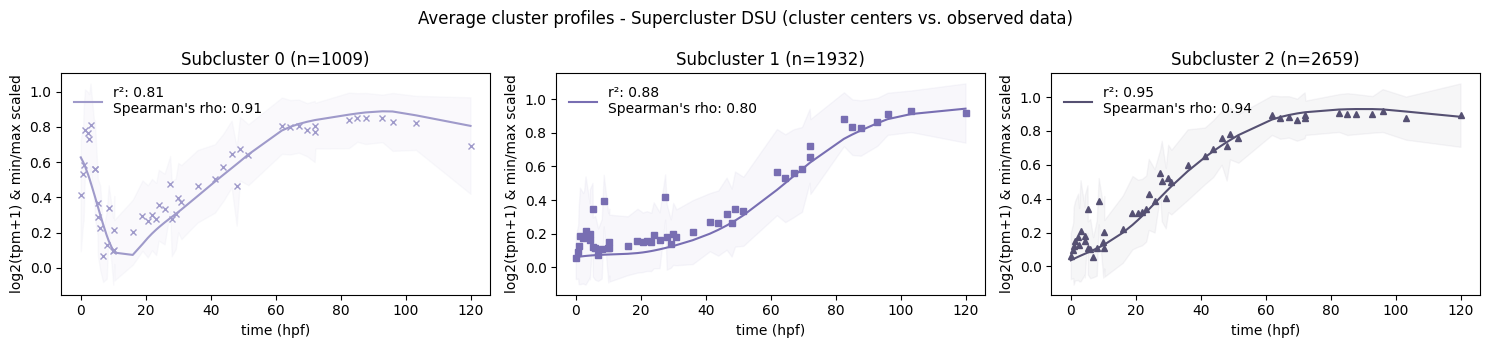

In [17]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

mean = ds.tpm.mean(dim=("time", "source"))
std = ds.tpm.std(dim=("time", "source"))
ds["tpm"] = (ds.tpm - mean) / std

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
marker_map = {0:"x", 1:"s", 2:"^"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 3),
             1:sns.color_palette("Blues_d", 3),
             2:sns.color_palette("Greens_d",3),
             3:sns.color_palette("Purples_d",3),}
gof=[]

#fig, ax = plt.subplots(2,2, figsize= (10, 6), sharex=True, sharey=True)
#ax=ax.flatten()
for k in range(4):
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/all_supercluster_{k}_centers.nc")
    sub_cluster = fuzzy_cntr.shape[0]
    fig, ax = plt.subplots(1,sub_cluster, figsize= (5*sub_cluster, 3.5), squeeze=False)
    ax=ax.flatten()

    for c in range(sub_cluster):
        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))

        center = fuzzy_cntr[c, :]

        ax[c].plot(fuzzy_cntr.time, center, 
                   label=f"r²: {r2(center, ds_c_mean):.2f} \nSpearman's rho: {spearmanr(center, ds_c_mean)[0]:.2f}", 
                   c=color_map[k][c])
        ax[c].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=color_map[k][c])
        ax[c].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
        ax[c].set(title=f"Subcluster {c} (n={ds_c.ensembl_gene_id.size})", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
        ax[c].legend(frameon=False)

    plt.suptitle(f"Average cluster profiles - Supercluster {cluster_map[k]} (cluster centers vs. observed data)")
    plt.tight_layout()
    plt.savefig(f"clustering/figs/subcluster_validation_{k}.png", dpi=300)
    plt.show()


## Cluster Heatmap

In [18]:
import seaborn as sns
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_heatmap_supercluster(annotation_path, cluster_col="supercluster", 
                  algo="hierarchical", source="all", norm="minmax", supercluster=None):

    # load annotated dataset (supercluster, subcluster, tpm)
    ann = xr.load_dataset(annotation_path)
    t_not = [5.16, 8.6, 27.52, 41.28]
    mask = ~ann.time.isin(t_not)
    ann = ann.sel(time=mask)

    if supercluster != None:
        ann = ann.where(ann.supercluster == supercluster, drop=True).sel(time=slice(0, 120))

    # select expression data: average over source, or pick one if specified
    if "source" in ann.tpm.dims:
        if source != "all":
            ann = ann.sel(source=source, drop=True)
            ann = ann.dropna(dim="time", how="all", subset=["tpm"])
            tpm = ann.tpm
        else:
            tpm = ann.tpm.mean(dim="source", skipna=True)
    else:
        tpm = ann.tpm

    tpm = tpm.transpose("ensembl_gene_id", "time")

    # drop genes with no valid time points
    valid = np.isfinite(tpm).any(dim="time")
    tpm = tpm.sel(ensembl_gene_id=valid)
    ann = ann.sel(ensembl_gene_id=tpm.ensembl_gene_id)

    # normalise per gene, same scheme as in fuzzy_cmeans
    tpm = np.log2(tpm+1)

    if norm == "minmax":
        X_z = (tpm - tpm.min("time")) / (tpm.max("time") - tpm.min("time"))
    elif norm == "zscore":
        X_z = (tpm - tpm.mean("time")) / tpm.std("time")
        
    elif norm == "meanmax":
        dev = tpm - tpm.mean("time")
        denom = abs(dev).max("time")
        denom = denom.where(denom > 0)
        X_z = dev / denom
    else:
        print("[ERROR] Provide valid normalisation method (minmax, meanmax)")
        return

    still_valid = np.isfinite(X_z).any(dim="time")
    print(f"[debug] genes surviving normalisation: {int(still_valid.sum())} / {still_valid.size}")

    X_z = X_z.sel(ensembl_gene_id=still_valid)
    ann = ann.sel(ensembl_gene_id=X_z.ensembl_gene_id)

    if X_z.sizes["ensembl_gene_id"] == 0:
        raise ValueError(
            f"No genes remain after filtering for source={source!r}. "
            "Check that this source has enough non-NaN time points per gene."
        )

    # cluster labels
    clusters = ann[cluster_col].values

    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time", skipna=True).values

    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]
    centers = (start_idx + end_idx) / 2

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])

    for c, y in zip(unique_clusters, centers):
        ax_bar.text(0.05, y, str(c),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black',
                    transform=ax_bar.transData)

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(expr_plot.values,
                cmap='Spectral_r',
                yticklabels=False, xticklabels=expr_plot.time.values,
                ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02})

    if supercluster != None:
        ax.set_title(f'Gene expression pattern in $D. rerio$ \n Cluster {supercluster}, n={int(still_valid.sum())} ({algo}, {source})', fontsize=12) 
    else:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, {source})', fontsize=12) 

    ax.set(xlabel='time (hpf)', ylabel='')

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(f"clustering/figs/{algo}_cluster_heatmap_{source}_{cluster_col}_{supercluster}.png",
                dpi=300, transparent=True)
    plt.show()

[debug] genes surviving normalisation: 22563 / 22563


C:\Users\mgrho\AppData\Local\Temp\ipykernel_28572\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


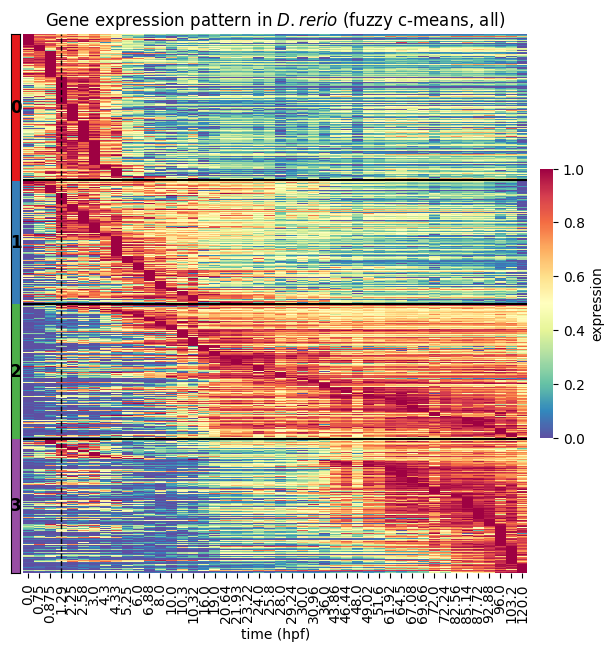

In [12]:
plot_heatmap_supercluster("clustering/results/all_gene_cluster_annotation_minmax.nc", cluster_col="supercluster", algo="fuzzy c-means", norm="minmax",)

[debug] genes surviving normalisation: 6132 / 6132


C:\Users\mgrho\AppData\Local\Temp\ipykernel_28572\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


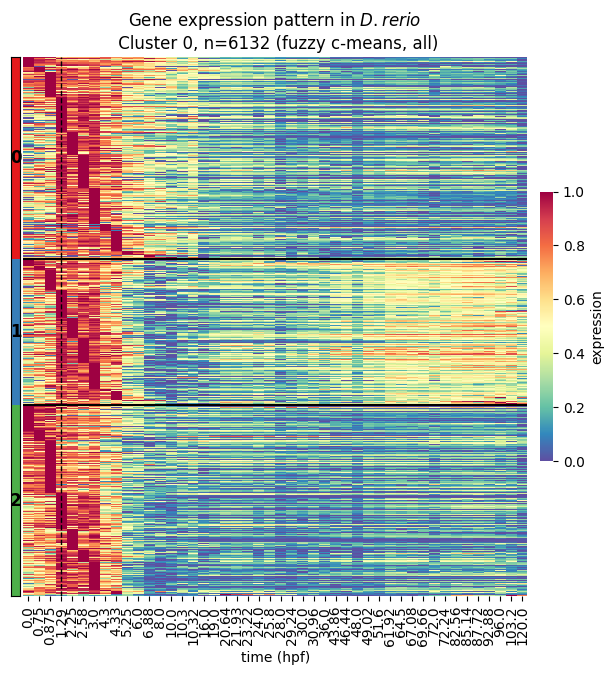

[debug] genes surviving normalisation: 5182 / 5182


C:\Users\mgrho\AppData\Local\Temp\ipykernel_28572\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


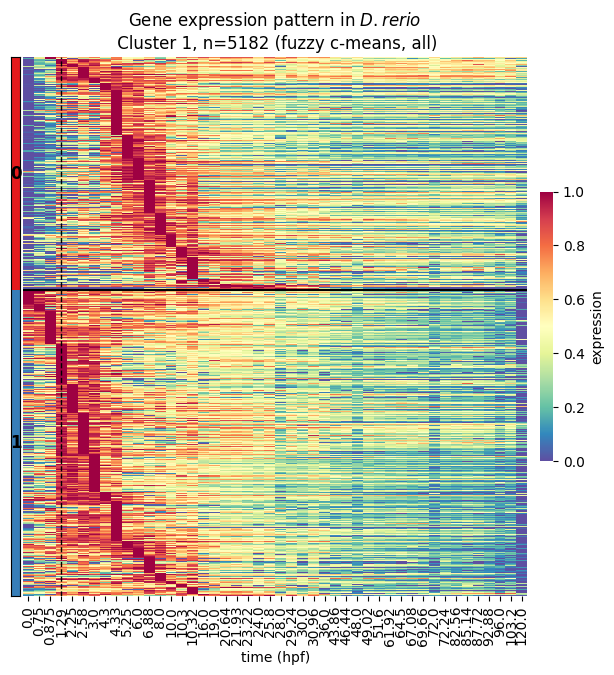

[debug] genes surviving normalisation: 5649 / 5649


C:\Users\mgrho\AppData\Local\Temp\ipykernel_28572\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


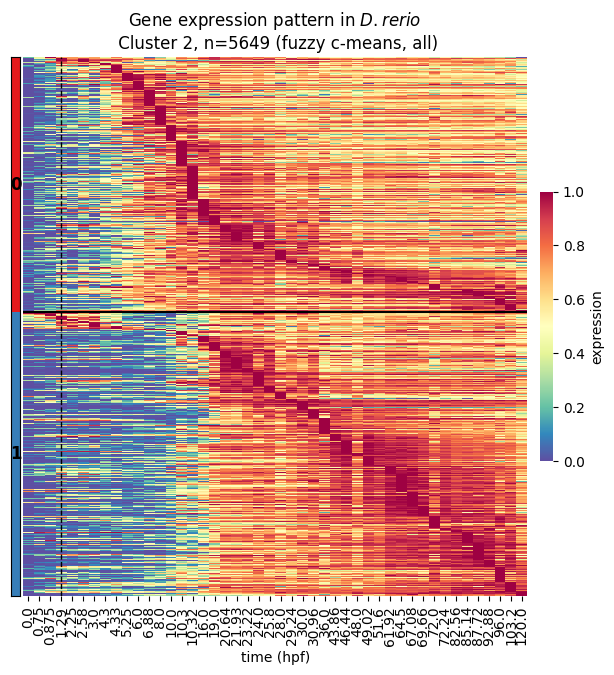

[debug] genes surviving normalisation: 5600 / 5600


C:\Users\mgrho\AppData\Local\Temp\ipykernel_28572\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


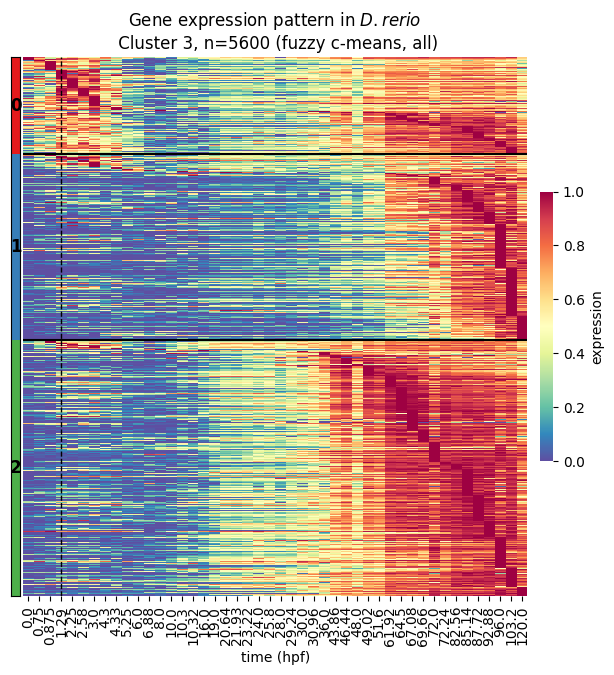

In [19]:
for i in range(4):
    plot_heatmap_supercluster("clustering/results/all_gene_cluster_annotation_minmax.nc", cluster_col="subcluster",
                algo="fuzzy c-means", source="all", supercluster=i)

## Model fit GOF

In [20]:
gof = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")
params.head()

,gene_id,beta_mean,delta_mean,sigma_y_mean,beta_std,delta_std,sigma_y_std,supercluster,supercluster_no,subcluster_no,...,delta_z_mean,t_reg_mean,t_rep_mean,t_zga_mean,alpha_std,delta_m_std,delta_z_std,t_reg_std,t_rep_std,t_zga_std
0,ENSDARG00000000001,0.243,0.11800,0.498,0.2120,0.09420,0.0447,SD,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENSDARG00000000002,0.172,0.00851,0.420,0.0198,0.00368,0.0395,DSU,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENSDARG00000000018,30.600,1.01000,0.536,9.4400,0.31500,0.0504,DSD,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENSDARG00000000019,7.610,0.16000,0.266,1.3900,0.02610,0.0245,SD,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENSDARG00000000068,0.976,0.10000,0.640,0.3540,0.03030,0.0581,SD,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


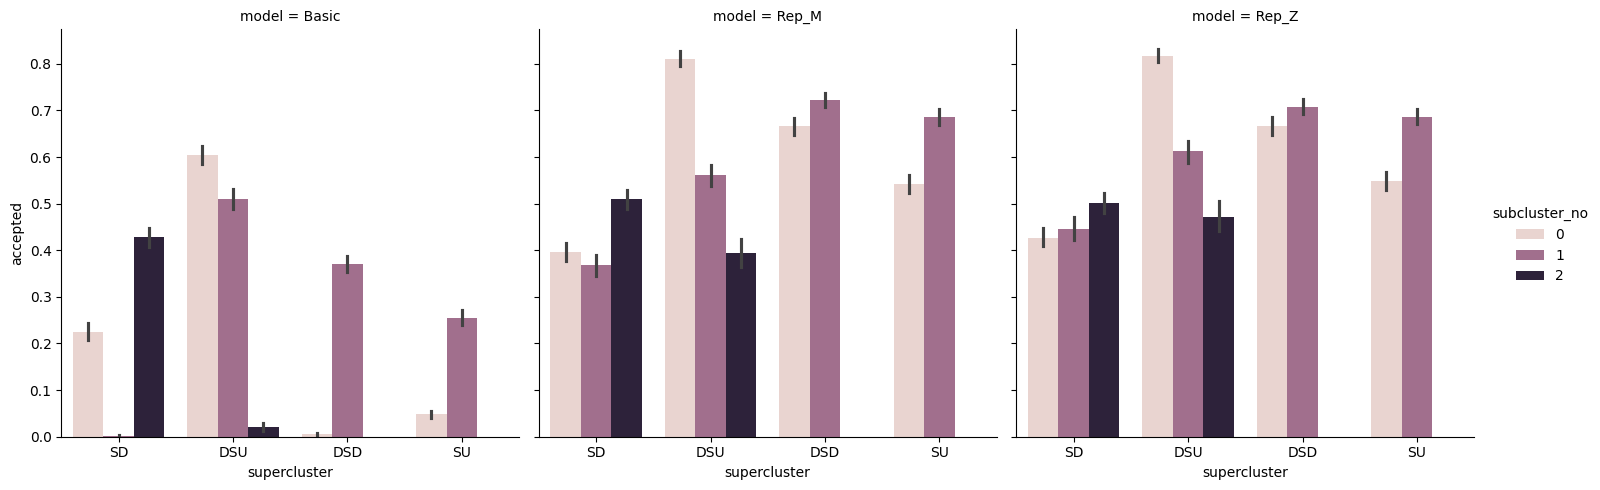

In [21]:
gof["accepted"] = (gof["rho"] > 0.7) & (gof["NRMSE"] < 0.3)
sns.catplot(gof, x ="supercluster", y="accepted", hue="subcluster_no", col="model", kind="bar", estimator="mean")

In [32]:
# result summary
with pd.ExcelWriter("results/evaluation_all.xlsx") as writer:
    gof.groupby(["model", "supercluster"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_all")
    gof.groupby(["model", "supercluster"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_all")
    gof_src.groupby(["model", "source"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_src")
    gof_src.groupby(["model", "source"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_src")
    gof_src.groupby(["model", "source", "supercluster"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_sc_src")
    gof_src.groupby(["model", "source", "supercluster"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_sc_src")


In [9]:
ds = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc").tpm.mean("source")
df = pd.DataFrame({"ensembl_gene_id": ds.ensembl_gene_id.values,
                   "supercluster_no":ds.supercluster.values,
                   "subluster_no":ds.subcluster.values,})
stats = xr.Dataset({"t_peak": ds.idxmax(dim="time"),})

stats_df = stats.to_dataframe().reset_index().drop(columns=["supercluster", "subcluster"])
df = df.merge(stats_df, on="ensembl_gene_id", how="left")

time = ds.time.values

In [23]:
# load data and combine with supercluster assignment
gof_all = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")
supercluster = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc")

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": supercluster["ensembl_gene_id"].values,
    "supercluster_no": supercluster["supercluster"].values,
    "subcluster_no": supercluster["subcluster"].values,
}).set_index("ensembl_gene_id")

cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
lookup["supercluster"]=lookup["supercluster_no"].map(cluster_names)

# Map onto df by gene_id
for df in [gof_all, gof_src, params]:
    df["supercluster"] = df["gene_id"].map(lookup["supercluster"])
    df["supercluster_no"] = df["gene_id"].map(lookup["supercluster_no"])
    df["subcluster_no"] = df["gene_id"].map(lookup["subcluster_no"])

gof_all.head()

,gene_id,NRMSE,NRMSE_lower,NRMSE_upper,LogLik,LogLik_lower,LogLik_upper,BIC,BIC_lower,BIC_upper,rho,pearsonr,WAIC,LOO,supercluster,supercluster_no,subcluster_no,model
0,ENSDARG00000000001,0.247397,0.207575,0.287312,-44.491680,-46.439812,-43.397228,101.364765,99.175860,105.261027,0.072557,0.569631,-47.244569,-47.368093,SD,0.0,2.0,Basic
1,ENSDARG00000000002,0.270265,0.176917,0.384435,-33.462400,-36.746632,-30.898830,79.306205,74.179064,85.874666,0.908860,0.947476,-35.081911,-35.113083,DSU,3.0,2.0,Basic
2,ENSDARG00000000018,0.304176,0.238389,0.386343,-49.140537,-52.698807,-46.312111,110.662477,105.005625,117.779017,-0.510609,0.085448,-50.931778,-50.956989,DSD,1.0,1.0,Basic
3,ENSDARG00000000019,0.213511,0.167638,0.259818,-4.288596,-6.666051,-2.738154,20.958594,17.857712,25.713505,0.391405,0.815170,-5.698864,-5.719403,SD,0.0,1.0,Basic
4,ENSDARG00000000068,0.299493,0.235036,0.379914,-60.592080,-62.927002,-59.135445,133.565563,130.652292,138.235407,0.408115,0.696970,-61.588580,-61.596542,SD,0.0,1.0,Basic


In [24]:
print(np.percentile(gof_all[gof_all["model"]=="Basic"].BIC, (5,95)))
print(np.percentile(gof_all[gof_all["model"]=="Rep_M"].BIC, (5,95)))
print(np.percentile(gof_all[gof_all["model"]=="Rep_Z"].BIC, (5,95)))

[  6.70865533 190.59530319]
[-19.53985853 156.48638469]
[-17.9872995 156.3797211]


In [25]:
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")


basic_bic = gof_all[gof_all["model"] == "Basic"].set_index("gene_id")["BIC"]
gof_all["delta_BIC"] = gof_all["BIC"] - gof_all["gene_id"].map(basic_bic)
gof_all[gof_all["delta_BIC"] < -6].value_counts("model") / 22530

model
Rep_Z    0.716644
Rep_M    0.671105
Name: count, dtype: float64

In [26]:
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
best_models = gof_all[gof_all["BIC_rank"] == 1]
best_models.value_counts("model") / 22530

model
Rep_Z    0.446427
Rep_M    0.369285
Basic    0.184288
Name: count, dtype: float64

C:\Users\mgrho\AppData\Local\Temp\ipykernel_28572\1486746792.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(best_models, x="model", palette=mod_color_dict, order=model_order)


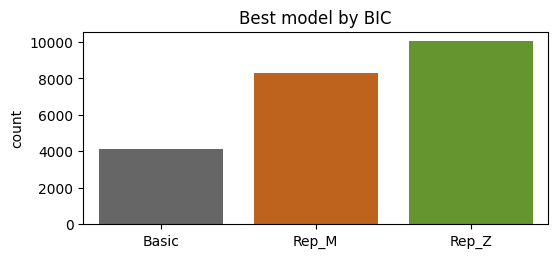

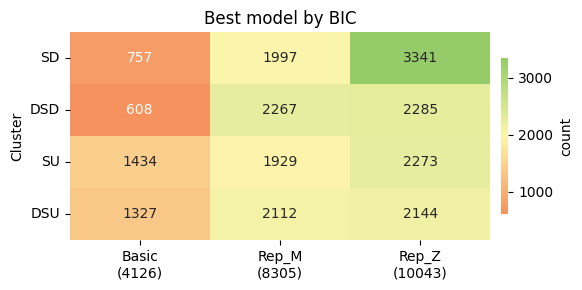

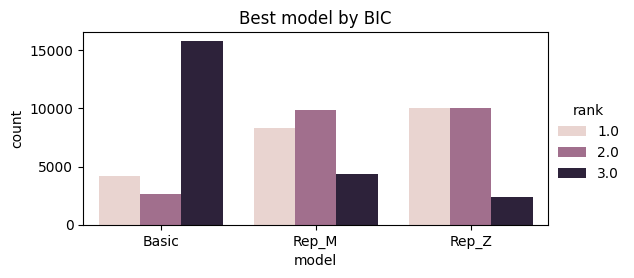

In [27]:
metr = "BIC"
best_models = gof_all.loc[gof_all.groupby("gene_id")[metr].idxmin()]
counts = pd.crosstab(best_models["model"], best_models["supercluster"])
counts = counts[["SD", "DSD", "SU", "DSU"]].T

labels = [f"{i}\n({counts[i].sum()})" for i in counts.columns]

fig = plt.figure(figsize=(6,2.5))
sns.countplot(best_models, x="model", palette=mod_color_dict, order=model_order)
plt.title(f"Best model by {metr}")
plt.xlabel("")
plt.savefig(f"results/figures/best_by_{metr}.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
sns.heatmap(counts, annot=True, fmt="d", cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': 'count', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)

ax.set(xlabel="", title=f"Best model by {metr}", ylabel="Cluster")
plt.yticks(rotation=0)
ax.set_xticklabels(labels)
plt.tight_layout()
plt.savefig(f"results/figures/best_by_{metr}_cluster.png", dpi=300)
plt.show()

#best_models = gof_all.loc[gof_all.groupby("gene_id")["BIC"].idxmin()]
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
best_models = gof_all[gof_all["BIC_rank"] == 1]

fig = plt.figure(figsize=(6,2.5))
sns.countplot(gof_all, x="model", hue="BIC_rank")
plt.title("Best model by BIC")
plt.savefig("results/figures/best_by_bic.png", dpi=300)
plt.legend(loc=(1.01, 0.2), frameon=False, title="rank")
plt.show()

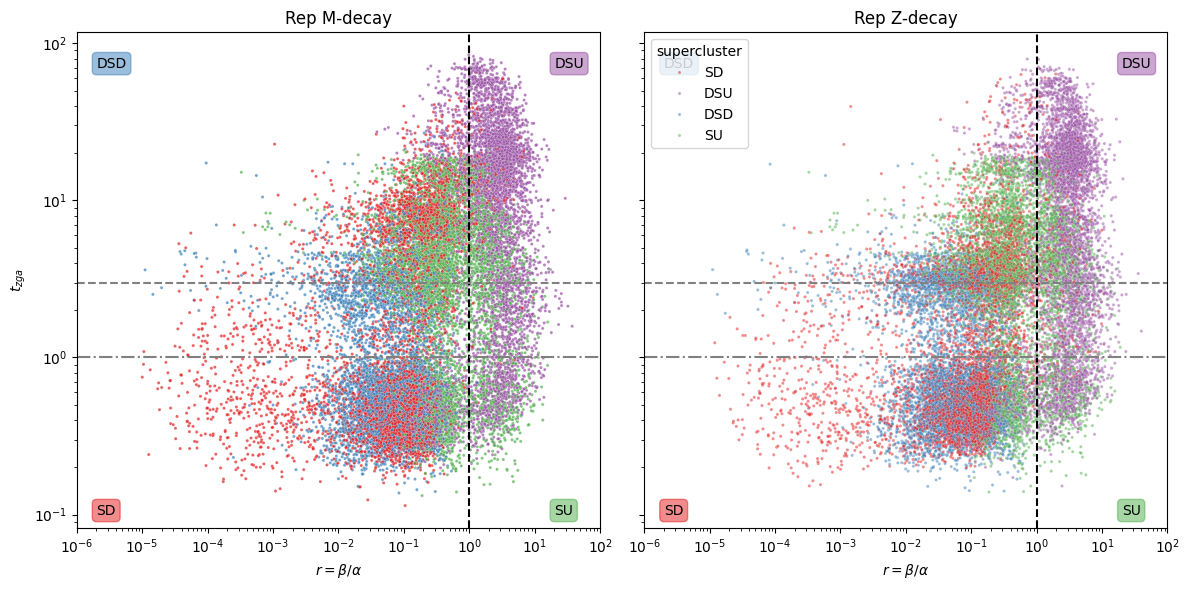

In [28]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

df = params[params["model"] != "Basic"].copy()
df["r"] = df["beta_mean"] / df["alpha_mean"]
df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)
sns.scatterplot(df_m, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", s=5, palette=cluster_color_dict, alpha=0.7, legend=False)
sns.scatterplot(df_z, x="r", y="t_zga_mean", ax=ax2, hue="supercluster", s=5, palette=cluster_color_dict, alpha=0.5, legend=True)

#sns.kdeplot(df_m, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=True, log_scale=True, fill=False, levels=4)
#sns.kdeplot(df_z, x="r",  y="t_zga_mean", hue="supercluster", ax=ax2, palette=cluster_color_dict, legend=True, log_scale=True, fill=False, levels=4)

ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title="Rep M-decay", xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax2.set(xlabel="$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title="Rep Z-decay", xscale="log", yscale="log", xlim=(1e-6, 1e2), )

ax1.axvline(1, c="k", ls="--")
ax2.axvline(1, c="k", ls="--")
ax1.axhline(3, c="gray", ls="--", label="ZGA")
ax2.axhline(3, c="gray", ls="--", label="ZGA")
ax1.axhline(1, c="gray", ls="-.", label="ZGA")
ax2.axhline(1, c="gray", ls="-.", label="ZGA")

ax1.text(x=2e-6, y=7e1, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e-6, y=1e-1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=7e1, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=1e-1, s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax2.text(x=2e-6, y=7e1, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e-6, y=1e-1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=7e1, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=1e-1, s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

plt.tight_layout()
plt.show()

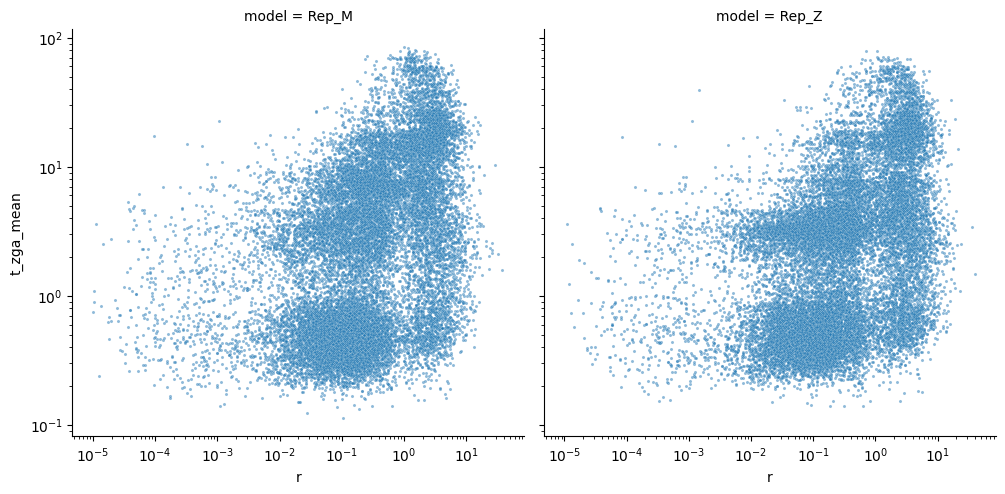

In [121]:
sns.relplot(df, x="r", y="t_zga_mean", col="model", s=5, alpha=0.5, legend=True)
plt.xscale("log")
plt.yscale("log")

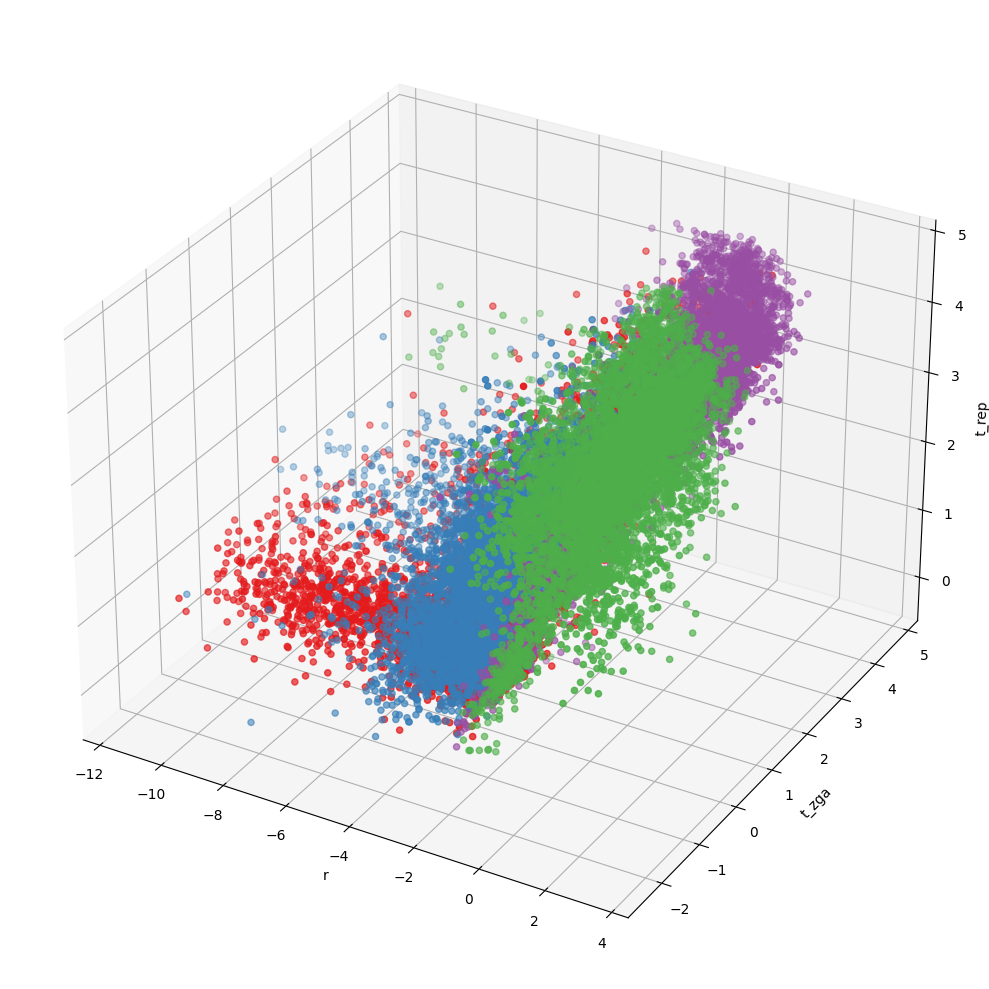

In [19]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')

df = params[params["model"] != "Basic"].copy()
df["r"] = df["beta_mean"] / df["alpha_mean"]
df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120) & (df["t_rep_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()


df_m = df_m.dropna(subset=["supercluster"])

df_m["r"] = np.log(df_m["r"])
df_m["t_zga_mean"] = np.log(df_m["t_zga_mean"])
df_m["t_rep_mean"] = np.log(df_m["t_rep_mean"])

for sc in df_m.supercluster.unique():
    df_m1 = df_m[df_m["supercluster"] == sc].copy()
    ax.scatter(df_m1["r"], df_m1["t_zga_mean"], df_m1["t_rep_mean"], color=cluster_color_dict[sc], label=sc)
       
ax.set_xlabel('r')
ax.set_ylabel('t_zga')
ax.set_zlabel('t_rep')
plt.tight_layout()
plt.show()

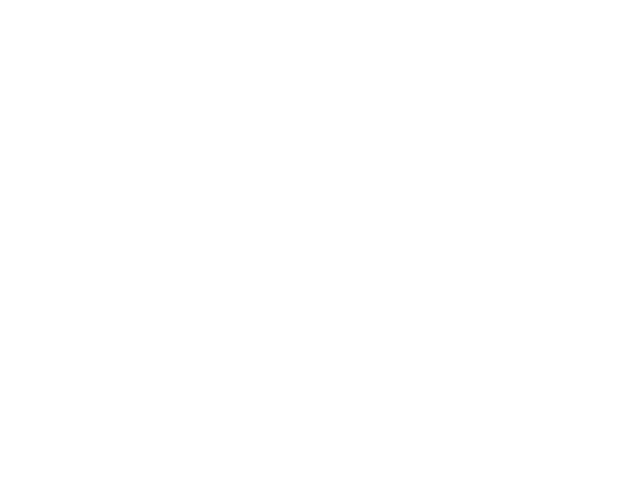

In [ ]:
# importing required libraries
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = Axes3D(fig)

for sc in df_m.supercluster.unique():
    df_m1 = df_m[df_m["supercluster"] == sc].copy()
    plot = ax.scatter(df_m1["r"].values, df_m1["t_zga_mean"].values, df_m1["t_rep_mean"].values, color=cluster_color_dict[sc])
plt.show()

In [16]:
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships


gof_src
example = from_memberships(
    [[],
     ['mase'],
     ['rho'],
     ['mase', 'rho'],
     ['nrmse'],
     ['mase', 'nrmse'],
     ['rho', 'nrmse'],
     ['mase', 'rho', 'nrmse'],
     ],
     data=[56, 283, 279, 582, 24, 90, 429, 157]
)

plot(example)

ModuleNotFoundError: No module named 'upsetplot'